In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

from pathlib import Path

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from estuary.util.plotting import plot_estuaries_ca

In [3]:
FIG_DIR = Path("/Users/kyledorman/data/estuary/display/seasonal_analysis/")

In [4]:
preds_all = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20251114-130229/merged_all_regions_timeseries_preds.csv"
)
skipped_regions = pd.read_csv("/Volumes/x10pro/estuary/geos/skipped_regions.csv")[
    "Site code"
].to_list()
preds_all["acquired"] = (
    pd.to_datetime(preds_all["acquired"], errors="coerce", utc=True)
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
    .astype("datetime64[ns]")
)
preds_all["date"] = preds_all.acquired.dt.date
preds_all["month"] = preds_all.acquired.dt.month
preds_all["year"] = preds_all.acquired.dt.year
preds_all = (
    preds_all[
        (~preds_all.region.isin(skipped_regions))
        & (preds_all.y_pred_unsure != 1)
        & (preds_all.year >= 2018)
    ]
    .copy()
    .sort_values(by=["region", "acquired"])
    .reset_index(drop=True)
)

preds_all.head()

,region,date,y_true,y_true_unsure,y_pred,y_prob,y_pred_unsure,acquired,source_tif,y_true_total,y_pred_total,month,year
0,11,2018-01-01,1,0,1,0.999982,0,2018-01-01 17:52:31,/Volumes/x10pro/estuary/ca_all/dove/results/20...,1,1,1,2018
1,11,2018-01-11,1,0,1,0.999976,0,2018-01-11 17:53:00,/Volumes/x10pro/estuary/ca_all/dove/results/20...,1,1,1,2018
2,11,2018-01-13,1,0,1,0.999980,0,2018-01-13 17:53:45,/Volumes/x10pro/estuary/ca_all/dove/results/20...,1,1,1,2018
3,11,2018-01-15,1,0,1,0.999985,0,2018-01-15 17:54:09,/Volumes/x10pro/estuary/ca_all/dove/results/20...,1,1,1,2018
4,11,2018-01-24,1,0,0,0.293239,0,2018-01-24 17:53:46,/Volumes/x10pro/estuary/ca_all/dove/results/20...,1,0,1,2018


In [5]:
gdf = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep.geojson").rename(
    columns={"Site code": "region"}
)
gdf = gdf[(gdf.skipped == False) & (gdf.potential_add == False)].copy()
gdf_points = gdf.copy()
gdf_points.geometry = gdf.to_crs("ESRI:54008").geometry.centroid.to_crs(gdf.crs)
gdf.head()

,region,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,potential_add,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,geometry
0,11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,False,SC-LPL,32.933,-117.260,32.931536,-117.256714,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
1,18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,False,SC-ZUM,34.015,-118.821,34.014565,-118.820618,"POLYGON ((-118.81685 34.01177, -118.81699 34.0..."
2,21,Ventura River,False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,4010_Ventura River,False,SC-VEN,34.276,-119.308,34.277309,-119.308329,"POLYGON ((-119.30473 34.27203, -119.3049 34.27..."
3,48,Carmel River,False,3080.0,Carmel River,PMEP,Lagoonal Estuary,Central California,216.0,37.647248,3080_Carmel River,False,CC-CAR,36.537,-121.927,36.537940,-121.923722,"POLYGON ((-121.92421 36.53429, -121.92412 36.5..."
4,50,Salinas River,False,3079.0,Salinas River,PMEP,Lagoonal Estuary,Central California,215.0,211.011888,3079_Salinas River,False,CC-SALI,36.748,-121.801,36.737644,-121.790315,"POLYGON ((-121.79521 36.74436, -121.79499 36.7..."


In [6]:
labels = pd.read_csv("/Users/kyledorman/data/estuary/dataset/open_closed.csv")
labels["acquired"] = pd.to_datetime(labels["acquired"], errors="coerce", utc=True)
labels = labels[(~labels.region.isin(skipped_regions))]
print(len(labels))
print(len(labels.region.unique()))

labels.groupby("region").acquired.size().min(), labels.groupby("region").acquired.size().max()

16296
72


(183, 283)

In [7]:
ts_labels = pd.read_csv("/Users/kyledorman/data/estuary/dataset/time_series.csv")
ts_labels["acquired"] = pd.to_datetime(ts_labels["acquired"], errors="coerce", utc=True)
ts_labels = ts_labels[(~ts_labels.region.isin(skipped_regions))]
print(len(ts_labels))
print(len(ts_labels.region.unique()))

ts_labels.groupby("region").acquired.size().min(), ts_labels.groupby("region").acquired.size().max()

10566
7


(1269, 1785)

In [8]:
ss_labels = pd.read_csv("/Volumes/x10pro/estuary/skysat/labels.csv")
ss_labels["acquired"] = pd.to_datetime(ss_labels["acquired"], errors="coerce", utc=True)
ss_labels = ss_labels[(~ss_labels.region.isin(skipped_regions))]
print(len(ss_labels))
print(len(ss_labels.region.unique()))

ss_labels.groupby("region").acquired.size().min(), ss_labels.groupby("region").acquired.size().max()

1654
69


(2, 135)

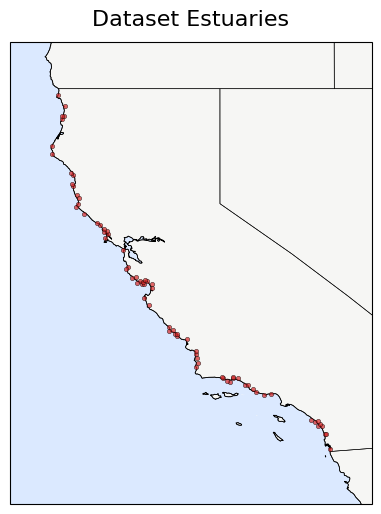

In [9]:
plot_estuaries_ca(
    gdf_points,
    markersize=10,
    jitter_deg=0.05,
    point_alpha=0.7,
    title="Dataset Estuaries",
    save_path=FIG_DIR / "all_estuaries.png",
)

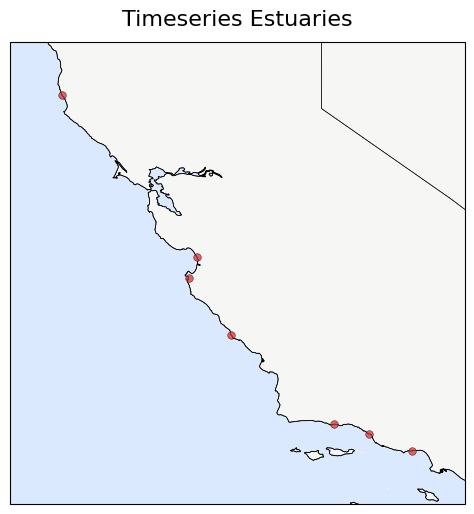

In [10]:
plot_estuaries_ca(
    gdf_points[gdf_points["region"].isin(ts_labels.region.unique())],
    markersize=30,
    point_alpha=0.7,
    title="Timeseries Estuaries",
    save_path=FIG_DIR / "all_timeseries_estuaries.png",
)

In [45]:
import pandas as pd


def _support_seconds_from_midpoints(t: np.ndarray) -> np.ndarray:
    """
    t: datetime64[ns] array, strictly increasing
    Returns per-sample support in seconds using midpoint boundaries.
    """
    t_ns = t.astype("datetime64[ns]").astype("int64")
    if len(t_ns) == 1:
        return np.array([0.0], dtype=float)

    mid = (t_ns[:-1] + t_ns[1:]) // 2

    left = np.empty_like(t_ns)
    right = np.empty_like(t_ns)

    left[0] = t_ns[0]
    left[1:] = mid

    right[-1] = t_ns[-1]
    right[:-1] = mid

    support_ns = right - left
    support_s = support_ns / 1e9
    return support_s.astype(float)


def smooth_binary_irregular(
    rdf: pd.DataFrame,
    *,
    time_col: str = "acquired",
    state_col: str = "y_pred",
    prob_col: str | None = "y_prob",
    one_sample_min_duration: pd.Timedelta = pd.Timedelta(days=8),
    multi_sample_min_duration: pd.Timedelta = pd.Timedelta(days=4),
    max_iter: int = 50,
    # Optional confidence gating: keep singletons if extremely confident
    keep_singleton_if_prob_ge: float | None = 0.95,  # for state==1
    keep_singleton_if_prob_le: float | None = 0.05,  # for state==0
) -> pd.Series:
    """
    Return a smoothed binary series for one region with irregular timestamps.

    Approach:
      - compute per-sample time support via midpoints
      - form runs (constant-state segments)
      - compute each run's total support duration and sample count
      - iteratively merge runs shorter than thresholds
          * if A-B-A, merge B into A
          * else merge into neighbor with larger adjacent support duration
      - optional: do not remove a singleton if y_prob is extremely confident
    """
    if rdf.empty:
        return pd.Series(dtype=int, index=rdf.index)

    # sort by time, keep original index so we can return aligned series
    rdf = rdf.sort_values(time_col)
    idx = rdf.index
    t = pd.to_datetime(rdf[time_col]).to_numpy(dtype="datetime64[ns]")

    state = rdf[state_col].to_numpy()
    state = state.astype(int)

    prob = None
    if prob_col is not None and prob_col in rdf.columns:
        prob = rdf[prob_col].to_numpy(dtype=float)

    support_s = _support_seconds_from_midpoints(t)
    one_thr_s = one_sample_min_duration.total_seconds()
    multi_thr_s = multi_sample_min_duration.total_seconds()

    # current working state array
    s = state.copy()

    for _ in range(max_iter):
        # identify runs
        change = np.empty_like(s, dtype=bool)
        change[0] = True
        change[1:] = s[1:] != s[:-1]
        run_id = np.cumsum(change) - 1  # 0..n_runs-1
        n_runs = run_id.max() + 1

        # run stats
        run_support = np.bincount(run_id, weights=support_s, minlength=n_runs)
        run_count = np.bincount(run_id, minlength=n_runs)

        # run boundaries (start/end indices in the sample array)
        run_start = np.full(n_runs, -1, dtype=int)
        run_end = np.full(n_runs, -1, dtype=int)

        # first occurrence of each run_id gives start
        # last occurrence gives end
        # do it in one pass
        for i, rid in enumerate(run_id):
            if run_start[rid] == -1:
                run_start[rid] = i
            run_end[rid] = i

        # decide which runs are "too short"
        too_short = np.zeros(n_runs, dtype=bool)
        for rid in range(n_runs):
            dur = run_support[rid]
            cnt = run_count[rid]
            thr = one_thr_s if cnt == 1 else multi_thr_s

            # optional confidence gating for singletons only
            if cnt == 1 and prob is not None:
                j = run_start[rid]
                if (
                    s[j] == 1
                    and keep_singleton_if_prob_ge is not None
                    and prob[j] >= keep_singleton_if_prob_ge
                ):
                    continue
                if (
                    s[j] == 0
                    and keep_singleton_if_prob_le is not None
                    and prob[j] <= keep_singleton_if_prob_le
                ):
                    continue

            if dur < thr:
                too_short[rid] = True

        if not too_short.any():
            break

        # perform merges by relabeling samples in short runs
        changed_any = False
        for rid in np.where(too_short)[0]:
            a = run_start[rid]
            b = run_end[rid]
            curr_state = s[a]

            prev_rid = rid - 1
            next_rid = rid + 1

            # cannot merge if only one run exists
            if n_runs == 1:
                continue

            prev_state = s[run_start[prev_rid]] if prev_rid >= 0 else None
            next_state = s[run_start[next_rid]] if next_rid < n_runs else None

            # prefer A-B-A merge
            if prev_rid >= 0 and next_rid < n_runs and prev_state == next_state:
                target_state = prev_state
            else:
                # otherwise merge into neighbor with larger support
                prev_support = run_support[prev_rid] if prev_rid >= 0 else -1.0
                next_support = run_support[next_rid] if next_rid < n_runs else -1.0

                if next_support > prev_support:
                    target_state = next_state
                else:
                    target_state = prev_state

                # if one side doesn't exist, fall back to the other
                if target_state is None:
                    target_state = next_state if prev_state is None else prev_state

            if target_state is None or target_state == curr_state:
                continue

            s[a : b + 1] = int(target_state)
            changed_any = True

        if not changed_any:
            break

    return pd.Series(s, index=idx, name=f"{state_col}_smooth")


preds_all = preds_all.copy()
preds_all["acquired"] = pd.to_datetime(preds_all["acquired"])

# start from raw prediction (or existing y_pred_smooth if you want)
preds_all["y_pred_smooth"] = preds_all["y_pred"].astype(int)

smoothed = preds_all.groupby("region", group_keys=False).apply(
    lambda rdf: smooth_binary_irregular(
        rdf,
        time_col="acquired",
        state_col="y_pred_smooth",
        prob_col="y_prob",
        one_sample_min_duration=pd.Timedelta(days=8),
        multi_sample_min_duration=pd.Timedelta(days=4),
        max_iter=50,
        keep_singleton_if_prob_ge=0.95,
        keep_singleton_if_prob_le=0.05,
    )
)

preds_all.loc[smoothed.index, "y_pred_smooth"] = smoothed.astype(int)


def count_switches(rdf):
    s = rdf.sort_values("acquired")["y_pred_smooth"].to_numpy(dtype=int)
    return int(np.sum(s[1:] != s[:-1]))


before = preds_all.assign(y_pred_smooth=preds_all["y_pred"]).groupby("region").apply(count_switches)
after = preds_all.groupby("region").apply(count_switches)

print(pd.DataFrame({"switches_before": before, "switches_after": after}).describe())

r = preds_all["region"].unique()[0]
tmp = preds_all[preds_all.region == r].sort_values("acquired")
tmp[["acquired", "y_prob", "y_pred", "y_pred_smooth"]].head(20)

       switches_before  switches_after
count        72.000000       72.000000
mean         75.000000       34.847222
std          46.266832       20.123324
min           0.000000        0.000000
25%          35.000000       21.000000
50%          75.000000       35.500000
75%         111.250000       47.250000
max         193.000000       92.000000


/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_36441/1015086926.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda rdf: smooth_binary_irregular(
/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_36441/1015086926.py:193: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  before = preds_all.assign(y_pred_smooth=preds_all["y_pred"]).groupby("region").apply(count_switches)
/var/folders/pr

,acquired,y_prob,y_pred,y_pred_smooth
0,2018-01-01 17:52:31.000,0.999982,1,1
1,2018-01-11 17:53:00.000,0.999976,1,1
2,2018-01-13 17:53:45.000,0.999980,1,1
3,2018-01-15 17:54:09.000,0.999985,1,1
4,2018-01-24 17:53:46.000,0.293239,0,1
5,2018-01-26 17:53:54.500,0.999367,1,1
6,2018-01-27 17:53:21.000,0.999633,1,1
7,2018-01-28 17:54:40.000,0.999859,1,1
8,2018-01-29 17:53:55.000,0.999549,1,1
9,2018-02-02 17:54:42.000,0.999966,1,1


In [13]:
# 1) Make sure date is datetime64[ns]
df = preds_all.copy()
df["date"] = pd.to_datetime(df["date"])

# 2) Get global date range
start = df["date"].min()
end = df["date"].max()

# 3) Build full MultiIndex: all regions × all dates
regions = df["region"].unique()
full_dates = pd.date_range(start, end, freq="D")

full_index = pd.MultiIndex.from_product(
    [regions, full_dates],
    names=["region", "date"],
)

# 4) Reindex and forward-fill within each region
full = df.set_index(["region", "date"]).sort_index().reindex(full_index)

# Forward-fill predictions within each region
full["y_pred_smooth"] = full["y_pred_smooth"].groupby(level="region").ffill()

# Forward-fill predictions within each region
full["y_prob"] = (
    full["y_prob"]
    .groupby(level="region")
    .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
    .ffill()
    .reset_index(level=0, drop=True)
)

region_min_date = df.groupby("region").date.min().max()
region_max_date = df.groupby("region").date.max().min()

full = full.reset_index()
full = full[full.date.between(region_min_date, region_max_date)].copy()
full = full.set_index(["region", "date"])

# 5) Get a region × time array for IoU
# Rows: region, Cols: date
y_mat = full["y_pred_smooth"].unstack("date").astype(int).to_numpy()

y_mat_prob = full["y_prob"].unstack("date").to_numpy()

region_labels = full["y_pred_smooth"].unstack("date").index.to_list()

date_axis = full["y_pred_smooth"].unstack("date").columns.to_list()

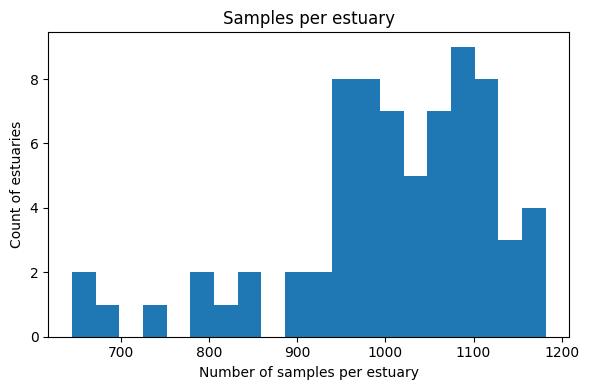

In [14]:
df = preds_all.copy()
start = df["acquired"].min().normalize()
end = df["acquired"].max().normalize()
all_days = pd.date_range(start, end, freq="D")
n_days_total = len(all_days)

samples_per_site = df.groupby("region").size().rename("n_samples")

plt.figure(figsize=(6, 4))
plt.hist(samples_per_site, bins=20)
plt.xlabel("Number of samples per estuary")
plt.ylabel("Count of estuaries")
plt.title("Samples per estuary")
plt.tight_layout()
plt.show()

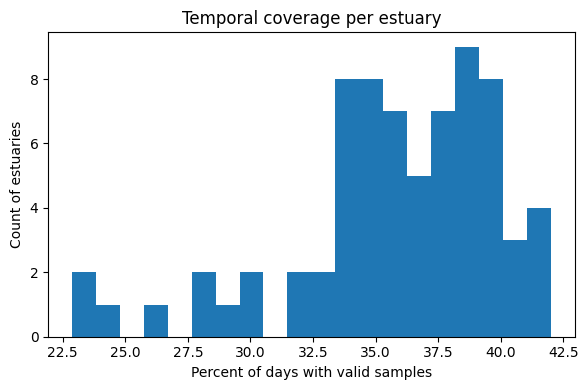

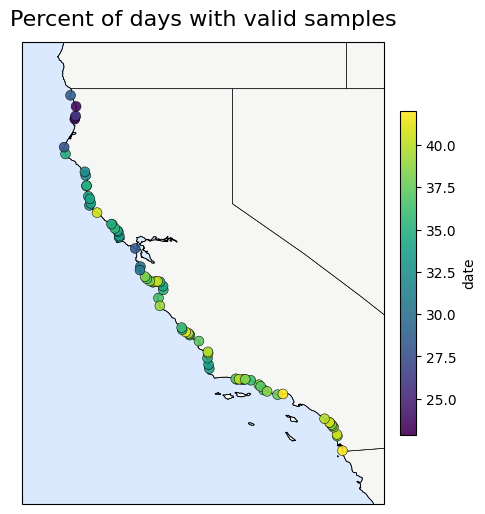

In [15]:
days_per_site = df.assign(date=df["acquired"].dt.normalize()).groupby("region")["date"].nunique()

pct_days_per_site = 100 * days_per_site / n_days_total

plt.figure(figsize=(6, 4))
plt.hist(pct_days_per_site, bins=20)
plt.xlabel("Percent of days with valid samples")
plt.ylabel("Count of estuaries")
plt.title("Temporal coverage per estuary")
plt.tight_layout()
plt.show()

g = gdf_points[["region", "geometry"]].set_index("region").join(pct_days_per_site, how="left")
plot_estuaries_ca(
    g,
    column="date",
    cmap="viridis",
    title="Percent of days with valid samples",
    add_colorbar=True,
    show=True,
)

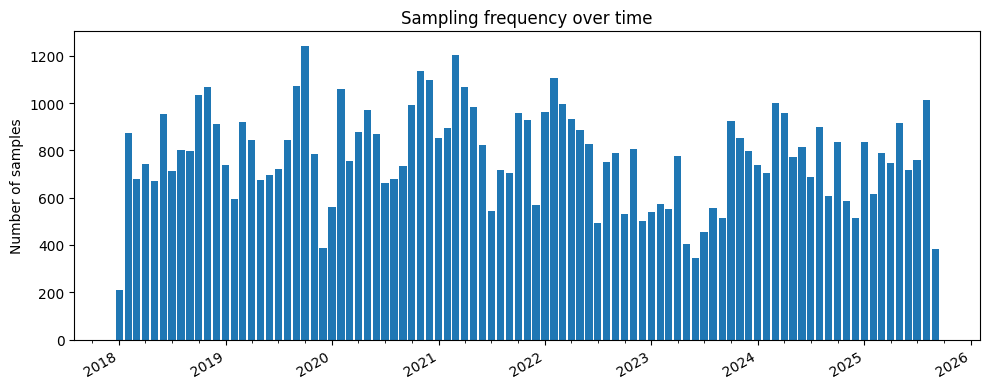

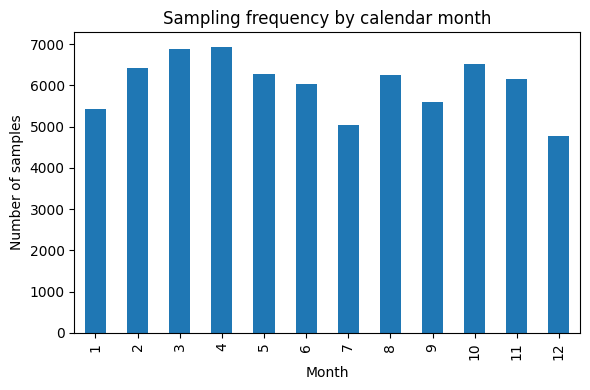

In [16]:
df["year_month"] = df["acquired"].dt.to_period("M")

samples_per_month = df.groupby("year_month").size().sort_index()

samples_per_month_dt = samples_per_month.copy()
samples_per_month_dt.index = samples_per_month_dt.index.to_timestamp()


fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    samples_per_month_dt.index,
    samples_per_month_dt.values,
    width=25,  # ~25 days looks good for monthly bars
)

ax.set_ylabel("Number of samples")
ax.set_title("Sampling frequency over time")

# Major ticks every year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Minor ticks every 3 months (no labels)
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

fig.autofmt_xdate()  # slight rotation if needed
plt.tight_layout()
plt.show()

df["month"] = df["acquired"].dt.month
samples_by_calendar_month = df.groupby("month").size()

plt.figure(figsize=(6, 4))
samples_by_calendar_month.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Number of samples")
plt.title("Sampling frequency by calendar month")
plt.tight_layout()
plt.show()

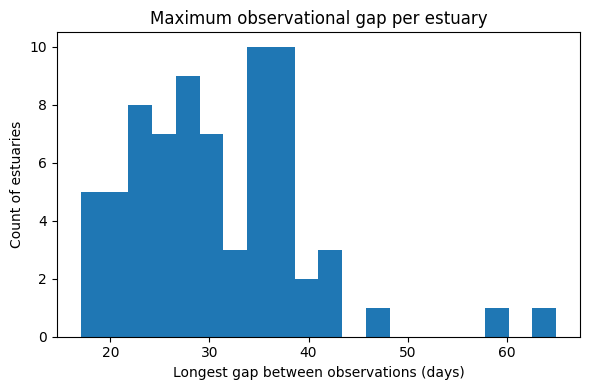

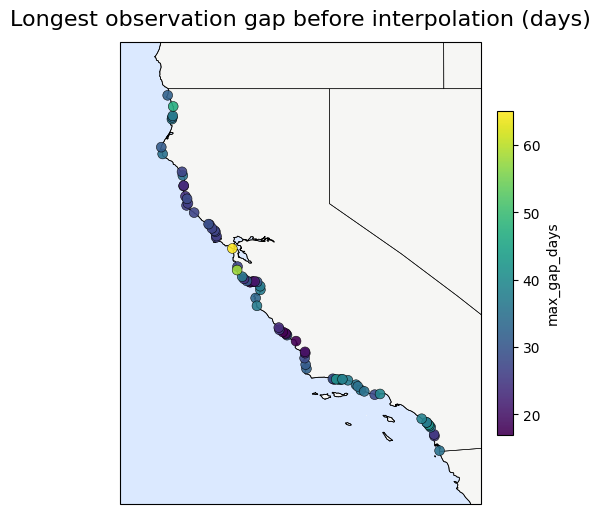

In [17]:
def max_gap_days(times: pd.Series) -> float:
    times = times.sort_values()
    gaps = times.diff().dt.days.dropna()
    return gaps.max() if len(gaps) else 0


max_gap_per_site = df.groupby("region")["acquired"].apply(max_gap_days).rename("max_gap_days")

plt.figure(figsize=(6, 4))
plt.hist(max_gap_per_site, bins=20)
plt.xlabel("Longest gap between observations (days)")
plt.ylabel("Count of estuaries")
plt.title("Maximum observational gap per estuary")
plt.tight_layout()
plt.show()

g = gdf_points.set_index("region").join(max_gap_per_site, how="left")
plot_estuaries_ca(
    g,
    column="max_gap_days",
    cmap="viridis",
    title="Longest observation gap before interpolation (days)",
    add_colorbar=True,
    show=True,
)

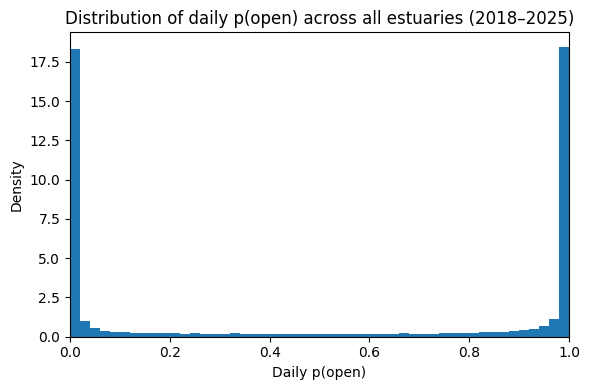

In [18]:
import matplotlib.pyplot as plt
import numpy as np

vals = y_mat_prob.reshape(-1)
vals = vals[np.isfinite(vals)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vals, bins=np.linspace(0, 1, 51), density=True)
ax.set_xlim(0, 1)
ax.set_xlabel("Daily p(open)")
ax.set_ylabel("Density")
ax.set_title("Distribution of daily p(open) across all estuaries (2018–2025)")
plt.tight_layout()
plt.show()

In [19]:
pd.Series(np.nanvar(y_mat_prob, axis=1), index=region_labels).sort_values(ascending=False)

57      2.338259e-01
66      2.316224e-01
68      2.249547e-01
31      2.226622e-01
70      2.223323e-01
            ...     
97      4.093823e-04
53      2.165074e-04
2161    7.398212e-05
2163    1.815290e-05
2162    2.296779e-08
Length: 72, dtype: float64

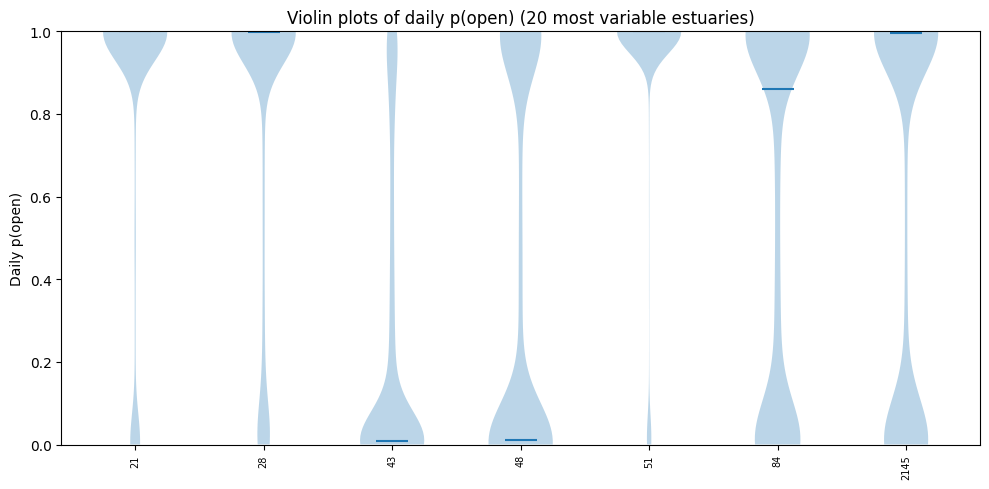

In [20]:
import pandas as pd

site_var = pd.Series(np.nanvar(y_mat_prob, axis=1), index=region_labels).sort_values(
    ascending=False
)
TIME_SERIES_REGIONS = ts_labels.region.unique()
subset = site_var.loc[TIME_SERIES_REGIONS].index.tolist()
subset_idx = [region_labels.index(r) for r in subset]
data_list = [y_mat_prob[i, :][np.isfinite(y_mat_prob[i, :])] for i in subset_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.violinplot(data_list, showmedians=True, showextrema=False)

ax.set_xticks(np.arange(1, len(subset) + 1))
ax.set_xticklabels(subset, rotation=90, fontsize=7)
ax.set_ylim(0, 1)
ax.set_ylabel("Daily p(open)")
ax.set_title("Violin plots of daily p(open) (20 most variable estuaries)")
plt.tight_layout()
plt.show()

In [21]:
# def ridgeplot_subset(
#     y_mat_prob: np.ndarray,
#     subset_idx: list[int],
#     subset_labels: list[str],
#     *,
#     order_by: str | None = None,  # None | "mean" | "var"
#     bins: int = 100,
#     smooth_sigma_bins: float = 1.0,
#     height: float = 0.9,
#     figsize=(10, 10),
# ):
#     Y = np.asarray(y_mat_prob, dtype=float)[subset_idx, :]

#     # Optional reordering *within* the subset
#     if order_by is not None:
#         means = np.nanmean(Y, axis=1)
#         vars_ = np.nanvar(Y, axis=1)

#         if order_by == "mean":
#             order = np.argsort(means)
#             title = "Ridge plot of daily p(open) (subset, ordered by mean openness)"
#         elif order_by == "var":
#             order = np.argsort(vars_)[::-1]
#             title = "Ridge plot of daily p(open) (subset, ordered by variability)"
#         else:
#             raise ValueError("order_by must be None, 'mean', or 'var'")

#         Y = Y[order]
#         labels = [subset_labels[i] for i in order]
#     else:
#         labels = subset_labels
#         title = "Ridge plot of daily p(open) (selected estuaries)"

#     x_edges = np.linspace(0, 1, bins + 1)
#     x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

#     fig, ax = plt.subplots(figsize=figsize)

#     for i, (v, lab) in enumerate(zip(Y, labels)):
#         v = v[np.isfinite(v)]
#         if len(v) == 0:
#             continue

#         dens, _ = np.histogram(v, bins=x_edges, density=True)
#         dens = _smooth1d(dens, sigma_bins=smooth_sigma_bins)

#         y0 = i * height
#         ax.fill_between(x_centers, y0, y0 + dens, alpha=0.85, linewidth=0.5)
#         ax.text(-0.02, y0, lab, va="center", ha="right", fontsize=8)

#     ax.set_xlim(0, 1)
#     ax.set_ylim(-height, len(labels) * height)
#     ax.set_yticks([])
#     ax.set_xlabel("Daily p(open)")
#     ax.set_title(title)
#     plt.tight_layout()
#     plt.show()

# region_to_idx = {r: i for i, r in enumerate(region_labels)}
# TIME_SERIES_REGIONS = ts_labels.region.unique().tolist()

# subset_idx = [
#     region_to_idx[r]
#     for r in TIME_SERIES_REGIONS
#     if r in region_to_idx
# ]
# subset_labels = [region_labels[i] for i in subset_idx]

# ridgeplot_subset(
#     y_mat_prob,
#     subset_idx,
#     subset_labels,
#     order_by=None,      # preserves TIME_SERIES_REGIONS order
#     figsize=(10, 6),
# )

67 / 72 estuaries have ≥ 2 switches
        switch_count  mean_open  mean_uncert
region                                      
65                 6   0.011399     0.004894
79                 4   0.989165     0.005068
23                88   0.551979     0.076849


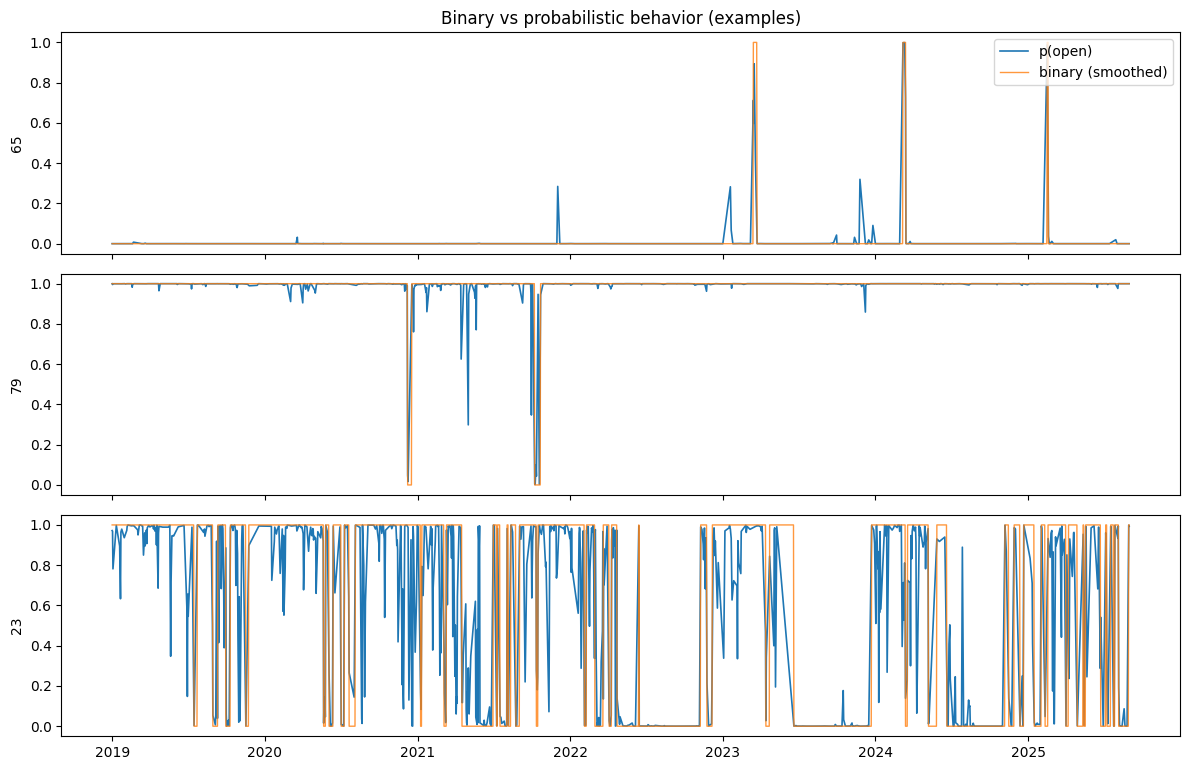

In [22]:
prob_wide = full["y_prob"].unstack("date")  # rows=region, cols=date
pred_wide = full["y_pred_smooth"].unstack("date").astype(int)

regions = prob_wide.index.tolist()
dates = prob_wide.columns.to_list()

Yp = prob_wide.to_numpy()
Yb = pred_wide.to_numpy()

import numpy as np
import pandas as pd

# Yb: binary array (n_regions, n_days)
# Yp: probability array (n_regions, n_days)

# count switches per region
switch_counts = np.nansum(np.abs(np.diff(Yb, axis=1)), axis=1)

# mean openness
mean_open = np.nanmean(Yp, axis=1)

# average uncertainty
mean_uncert = np.nanmean(Yp * (1 - Yp), axis=1)

stats = pd.DataFrame(
    {
        "region": region_labels,
        "switch_count": switch_counts,
        "mean_open": mean_open,
        "mean_uncert": mean_uncert,
    }
).set_index("region")

MIN_SWITCHES = 2

dynamic = stats[stats["switch_count"] >= MIN_SWITCHES]
print(f"{len(dynamic)} / {len(stats)} estuaries have ≥ {MIN_SWITCHES} switches")

example_closed = dynamic["mean_open"].idxmin()
example_open = dynamic["mean_open"].idxmax()
example_trans = dynamic["switch_count"].idxmax()

example_regions = [example_closed, example_open, example_trans]

print(dynamic.loc[example_regions])


def plot_examples(full, regions_to_plot, start=None, end=None, title=None):
    prob = full["y_prob"].unstack("date")
    pred = full["y_pred_smooth"].unstack("date").astype(float)

    if start is not None or end is not None:
        prob = prob.loc[:, prob.columns.to_series().between(start, end)]
        pred = pred.loc[:, pred.columns.to_series().between(start, end)]

    n = len(regions_to_plot)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6 * n), sharex=True)

    if n == 1:
        axes = [axes]

    for ax, r in zip(axes, regions_to_plot):
        p = prob.loc[r].to_numpy()
        b = pred.loc[r].to_numpy()

        ax.plot(prob.columns, p, linewidth=1.2, label="p(open)")
        ax.plot(prob.columns, b, linewidth=1.0, alpha=0.8, label="binary (smoothed)")

        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel(r)

    axes[0].legend(loc="upper right")
    if title:
        axes[0].set_title(title)

    plt.tight_layout()
    plt.show()


plot_examples(
    full,
    example_regions,
    start="2019-01-01",
    end="2025-12-31",
    title="Binary vs probabilistic behavior (examples)",
)

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_36441/197758596.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_u.groupby("bin")


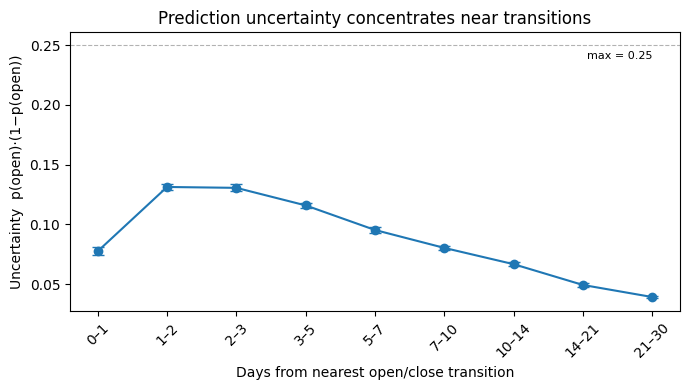

In [23]:
def distance_to_nearest_switch(b: np.ndarray) -> np.ndarray:
    b = b.astype(int)
    T = len(b)
    switches = np.zeros(T, dtype=bool)
    switches[1:] = b[1:] != b[:-1]

    idx = np.where(switches)[0]
    if len(idx) == 0:
        return np.full(T, np.inf)

    dist = np.empty(T, dtype=int)
    for t in range(T):
        dist[t] = np.min(np.abs(idx - t))
    return dist


MAX_D = 30  # days from switch to consider

all_dist = []
all_uncert = []
all_p = []

for i in range(Yp.shape[0]):
    p = Yp[i]
    b = Yb[i]

    if not np.isfinite(p).all():
        continue

    dist = distance_to_nearest_switch(b)
    u = p * (1 - p)

    m = dist <= MAX_D
    all_dist.append(dist[m])
    all_uncert.append(u[m])
    all_p.append(p[m])

all_dist = np.concatenate(all_dist)
all_uncert = np.concatenate(all_uncert)
all_p = np.concatenate(all_p)

import numpy as np
import pandas as pd

bins = np.array([0, 1, 2, 3, 5, 7, 10, 14, 21, 30])
labels = [f"{bins[i]}–{bins[i + 1]}" for i in range(len(bins) - 1)]

df_u = pd.DataFrame(
    {
        "dist": all_dist,
        "uncert": all_uncert,
    }
)

df_u["bin"] = pd.cut(df_u["dist"], bins=bins, labels=labels, right=False)

summary = (
    df_u.groupby("bin")
    .agg(
        mean_u=("uncert", "mean"),
        n=("uncert", "count"),
        std=("uncert", "std"),
    )
    .reset_index()
)

summary["sem"] = summary["std"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["sem"]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(summary))
ax.errorbar(
    x,
    summary["mean_u"],
    yerr=summary["ci95"],
    fmt="o-",
    capsize=4,
)

ax.set_xticks(x)
ax.set_xticklabels(summary["bin"], rotation=45)
ax.set_xlabel("Days from nearest open/close transition")
ax.set_ylabel("Uncertainty  p(open)·(1−p(open))")
ax.set_title("Prediction uncertainty concentrates near transitions")

ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(len(x) - 1, 0.245, "max = 0.25", ha="right", va="top", fontsize=8)

plt.tight_layout()
plt.show()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_36441/1346251325.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mid.groupby("bin")


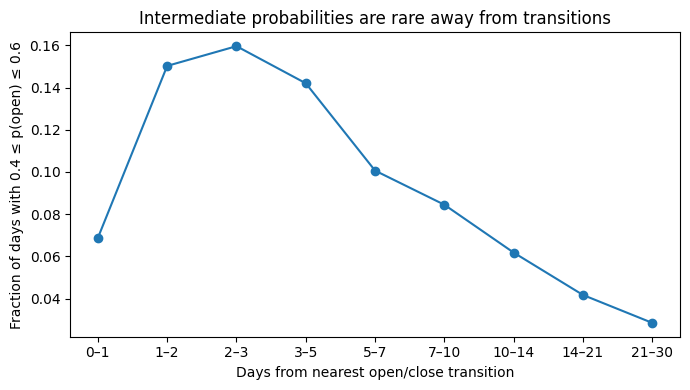

In [24]:
MID_LO = 0.4
MID_HI = 0.6

mid_mask = (all_p >= MID_LO) & (all_p <= MID_HI)

df_mid = pd.DataFrame(
    {
        "dist": all_dist,
        "is_mid": mid_mask.astype(int),
    }
)

df_mid["bin"] = pd.cut(df_mid["dist"], bins=bins, labels=labels, right=False)

mid_summary = (
    df_mid.groupby("bin")
    .agg(
        frac_mid=("is_mid", "mean"),
        n=("is_mid", "count"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    mid_summary["bin"],
    mid_summary["frac_mid"],
    marker="o",
)

ax.set_xlabel("Days from nearest open/close transition")
ax.set_ylabel("Fraction of days with 0.4 ≤ p(open) ≤ 0.6")
ax.set_title("Intermediate probabilities are rare away from transitions")

plt.tight_layout()
plt.show()

Missing in gdf_points: [] 
Missing in full: [] 


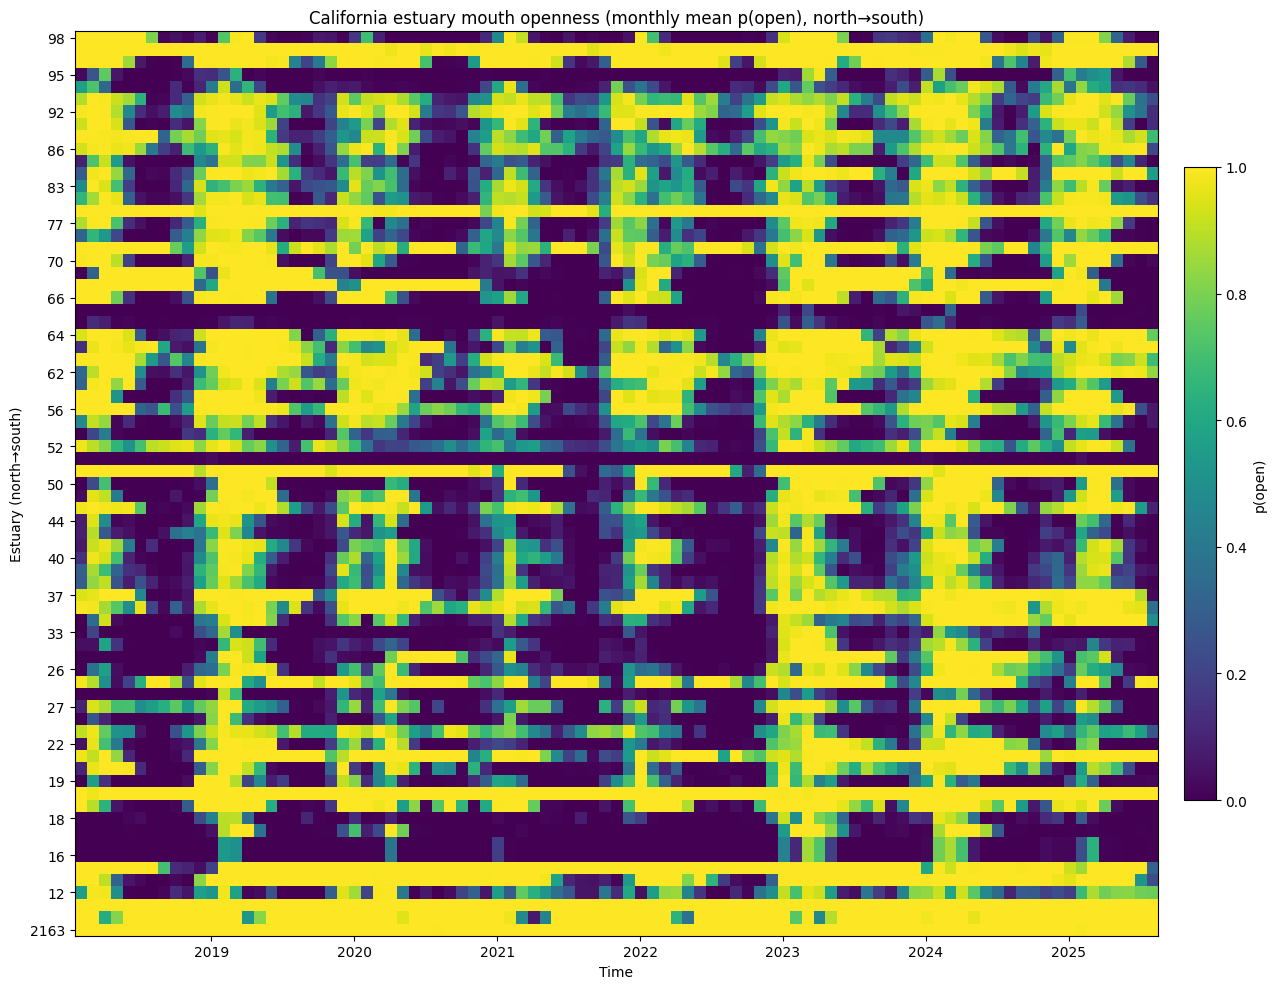

In [25]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure lon/lat CRS
if gdf_points.crs is None or gdf_points.crs.to_epsg() != 4326:
    raise ValueError("gdf_points must be in EPSG:4326 (lon/lat)")

gdf_points = gdf_points.copy()
gdf_points["lat"] = gdf_points.geometry.y
gdf_points["lon"] = gdf_points.geometry.x

# Order regions north->south (descending latitude)
regions_n2s = gdf_points.sort_values("lat", ascending=False)["region"].astype(str).tolist()

regions_in_full = set(full.index.get_level_values("region").astype(str).unique())
regions_in_gdf = set(gdf_points["region"].astype(str).unique())

missing_in_gdf = sorted(regions_in_full - regions_in_gdf)
missing_in_full = sorted(regions_in_gdf - regions_in_full)

print("Missing in gdf_points:", missing_in_gdf[:10], "..." if len(missing_in_gdf) > 10 else "")
print("Missing in full:", missing_in_full[:10], "..." if len(missing_in_full) > 10 else "")

prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])
prob["ym"] = prob["date"].dt.to_period("M").dt.to_timestamp()

monthly = prob.groupby(["region", "ym"])["p"].mean().unstack("ym")
monthly.index = monthly.index.astype(str)

# Reindex rows to north->south
monthly = monthly.reindex(regions_n2s)

# Drop regions with no data (if any)
monthly = monthly.dropna(axis=0, how="all")

fig, ax = plt.subplots(figsize=(14, 10))

M = monthly.to_numpy(dtype=float)
dates = monthly.columns.to_pydatetime()

im = ax.imshow(M, aspect="auto", vmin=0, vmax=1)

# X axis: real dates
ax.set_xticks(np.arange(len(dates)))
# show yearly ticks only to avoid clutter
year_ticks = [i for i, d in enumerate(dates) if d.month == 1]
ax.set_xticks(year_ticks)
ax.set_xticklabels([dates[i].strftime("%Y") for i in year_ticks], rotation=0)

# Y axis: estuary labels (too many to label all; show every N)
y_labels = monthly.index.tolist()
step = max(1, len(y_labels) // 20)  # ~20 labels max
ax.set_yticks(np.arange(0, len(y_labels), step))
ax.set_yticklabels([y_labels[i] for i in range(0, len(y_labels), step)])

ax.set_title("California estuary mouth openness (monthly mean p(open), north→south)")
ax.set_xlabel("Time")
ax.set_ylabel("Estuary (north→south)")

cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("p(open)")

plt.tight_layout()
plt.show()

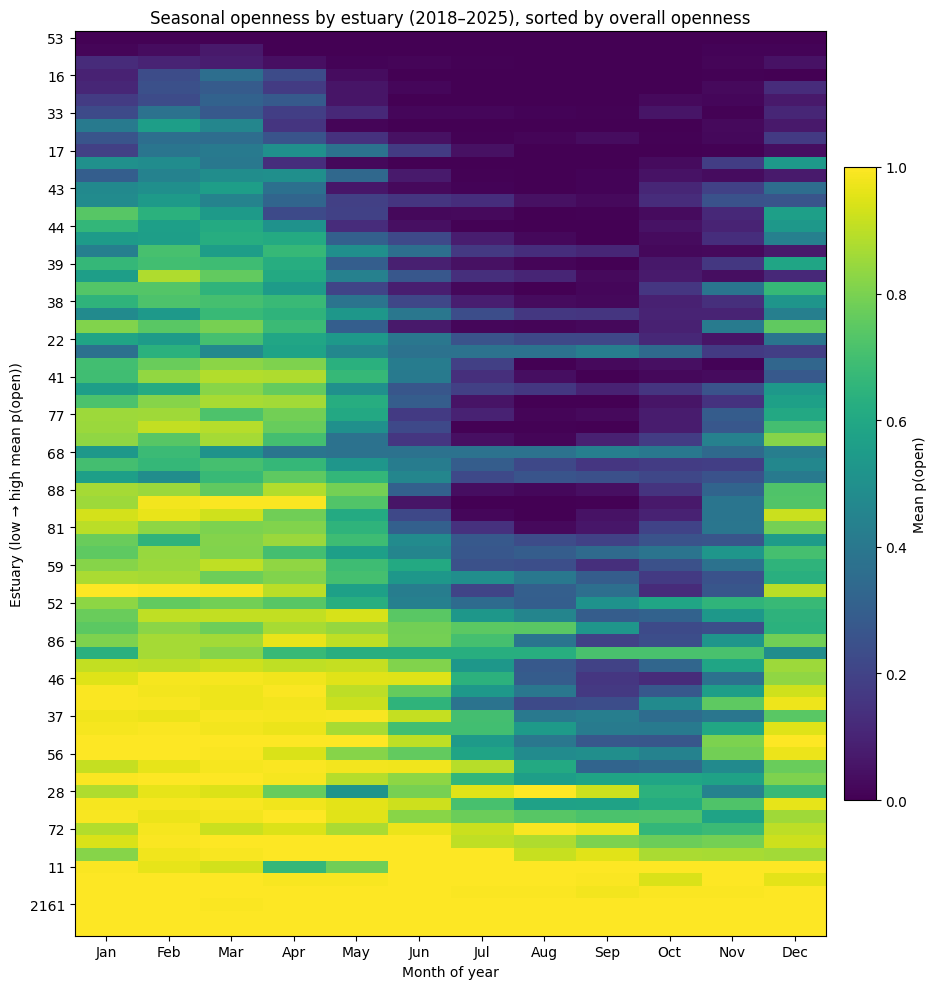

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])
prob["month"] = prob["date"].dt.month

# 1) Overall openness per estuary (mean p(open) over all days)
overall_open = (
    prob.groupby("region")["p"].mean().sort_values(ascending=True)  # closed -> open
)

regions_by_open = overall_open.index.tolist()

# 2) Month-of-year mean p(open) per estuary
moy = prob.groupby(["region", "month"])["p"].mean().unstack("month").reindex(columns=range(1, 13))

# 3) Reorder by overall openness
moy = moy.reindex(regions_by_open).dropna(axis=0, how="all")

# 4) Plot
fig, ax = plt.subplots(figsize=(10, 10))

M = moy.to_numpy(dtype=float)
im = ax.imshow(M, aspect="auto", vmin=0, vmax=1)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(np.arange(12))
ax.set_xticklabels(month_labels)

# y labels thinned (72 is too many)
y_labels = moy.index.tolist()
step = max(1, len(y_labels) // 20)
ax.set_yticks(np.arange(0, len(y_labels), step))
ax.set_yticklabels([y_labels[i] for i in range(0, len(y_labels), step)])

ax.set_title("Seasonal openness by estuary (2018–2025), sorted by overall openness")
ax.set_xlabel("Month of year")
ax.set_ylabel("Estuary (low → high mean p(open))")

cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Mean p(open)")

plt.tight_layout()
plt.show()

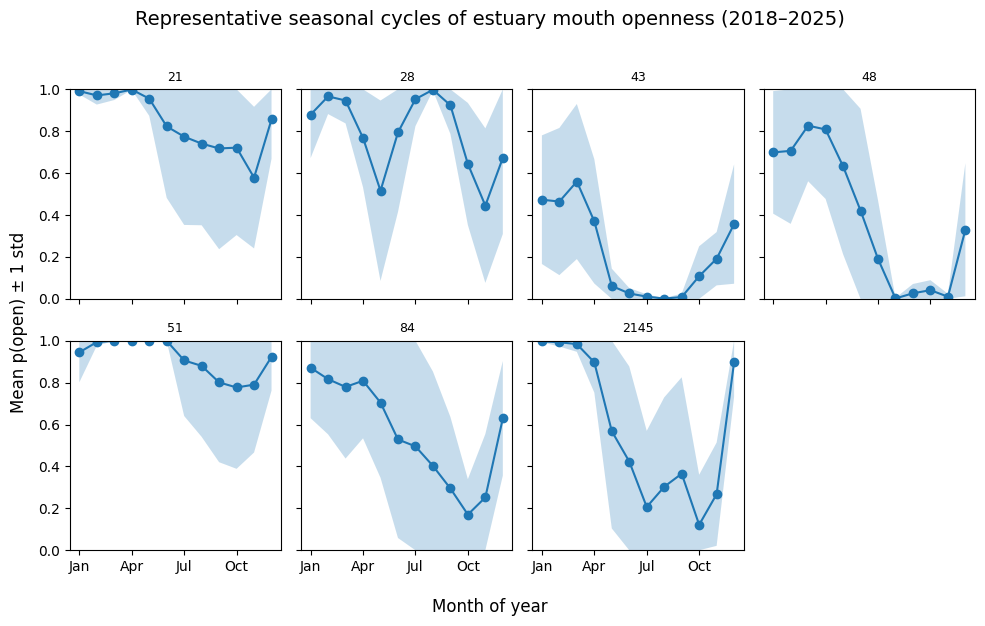

In [27]:
import numpy as np
import pandas as pd

rep_regions = list(TIME_SERIES_REGIONS)

prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])
prob["year"] = prob["date"].dt.year
prob["month"] = prob["date"].dt.month

# 1) monthly mean per (region, year, month)
rym = prob.groupby(["region", "year", "month"])["p"].mean().reset_index(name="month_mean")

# 2) across-year mean/std of those monthly means per (region, month)
moments = (
    rym.groupby(["region", "month"])["month_mean"]
    .agg(mean="mean", std="std", n_years="count")
    .reset_index()
)

mean_moy = moments.pivot(index="region", columns="month", values="mean").reindex(
    columns=range(1, 13)
)

std_moy = moments.pivot(index="region", columns="month", values="std").reindex(columns=range(1, 13))

n_years_moy = moments.pivot(index="region", columns="month", values="n_years").reindex(
    columns=range(1, 13)
)


def plot_seasonal_small_multiples_with_std(
    mean_moy: pd.DataFrame,
    std_moy: pd.DataFrame,
    regions: list[str],
    *,
    ncols: int = 4,
    figsize=(13, 9),
):
    regions = [r for r in regions if r in mean_moy.index]
    n = len(regions)
    nrows = int(np.ceil(n / ncols))
    months = np.arange(1, 13)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, r in zip(axes, regions):
        mu = mean_moy.loc[r].to_numpy(dtype=float)
        sd = std_moy.loc[r].to_numpy(dtype=float)

        lo = np.clip(mu - sd, 0, 1)
        hi = np.clip(mu + sd, 0, 1)

        ax.fill_between(months, lo, hi, alpha=0.25)
        ax.plot(months, mu, marker="o", linewidth=1.5)

        ax.set_title(r, fontsize=9)
        ax.set_ylim(0, 1)
        ax.set_xticks([1, 4, 7, 10])
        ax.set_xticklabels(["Jan", "Apr", "Jul", "Oct"])

    for ax in axes[len(regions) :]:
        ax.axis("off")

    fig.supylabel("Mean p(open) ± 1 std", fontsize=12)
    fig.supxlabel("Month of year", fontsize=12)
    fig.suptitle(
        "Representative seasonal cycles of estuary mouth openness (2018–2025)",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


plot_seasonal_small_multiples_with_std(
    mean_moy,
    std_moy,
    rep_regions,
    ncols=4,
    figsize=(10, 6),
)

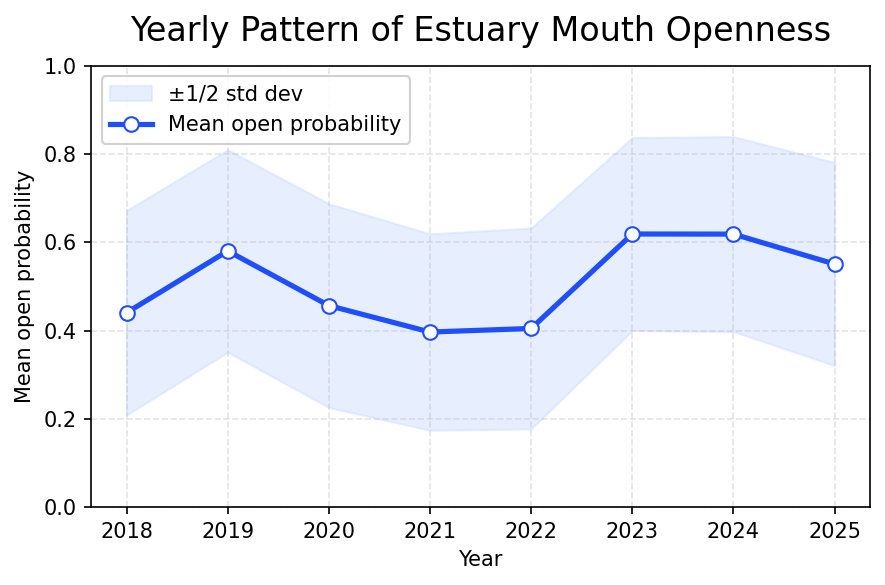

In [28]:
year_pct = []
year_pct_std = []
for year in range(2018, 2026):
    idx = np.array([i for i, d in enumerate(date_axis) if d.year == year])
    vals = y_mat_prob[:, idx]
    year_pct.append(vals.mean())
    year_pct_std.append(vals.std() / 2)

year_pct = np.array(year_pct)
year_pct_std = np.array(year_pct_std)
years = np.arange(2018, 2026)

plt.figure(figsize=(6, 4), dpi=150)

# Shaded variability
plt.fill_between(
    years,
    year_pct - year_pct_std,
    year_pct + year_pct_std,
    color="#c5d8ff",
    alpha=0.4,
    label="±1/2 std dev",
)

# Line for monthly mean
plt.plot(
    years,
    year_pct,
    color="#1f4eff",
    linewidth=2.5,
    marker="o",
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="#1f4eff",
    label="Mean open probability",
)

# Fancy x-axis labels
plt.xticks(years, years)

plt.ylabel("Mean open probability")
plt.xlabel("Year")
plt.title("Yearly Pattern of Estuary Mouth Openness", fontsize=16, pad=12)

plt.grid(True, linestyle="--", alpha=0.35)
plt.ylim(0, 1)

plt.legend(frameon=True, facecolor="white", framealpha=0.9)

plt.tight_layout()

# plt.savefig(FIG_DIR / "pct_open_month.png")

plt.show()

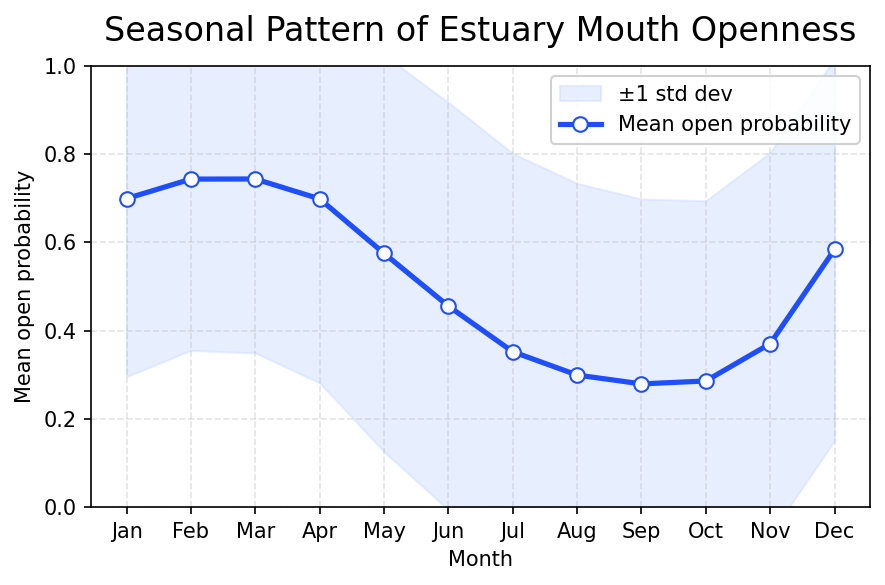

In [29]:
# Compute monthly percent open
month_pct = []
month_pct_std = []  # optional variability shading
for month in range(1, 13):
    idx = np.array([i for i, d in enumerate(date_axis) if d.month == month])
    vals = y_mat_prob[:, idx]
    month_pct.append(vals.mean())
    month_pct_std.append(vals.std())

months = np.arange(1, 13)

plt.figure(figsize=(6, 4), dpi=150)

# Shaded variability
plt.fill_between(
    months,
    np.array(month_pct) - np.array(month_pct_std),
    np.array(month_pct) + np.array(month_pct_std),
    color="#c5d8ff",
    alpha=0.4,
    label="±1 std dev",
)

# Line for monthly mean
plt.plot(
    months,
    month_pct,
    color="#1f4eff",
    linewidth=2.5,
    marker="o",
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="#1f4eff",
    label="Mean open probability",
)

# Fancy x-axis labels
plt.xticks(
    months, ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.ylabel("Mean open probability")
plt.xlabel("Month")
plt.title("Seasonal Pattern of Estuary Mouth Openness", fontsize=16, pad=12)

plt.grid(True, linestyle="--", alpha=0.35)
plt.ylim(0, 1)

plt.legend(frameon=True, facecolor="white", framealpha=0.9)

plt.tight_layout()

# plt.savefig(FIG_DIR / "pct_open_month.png")

plt.show()

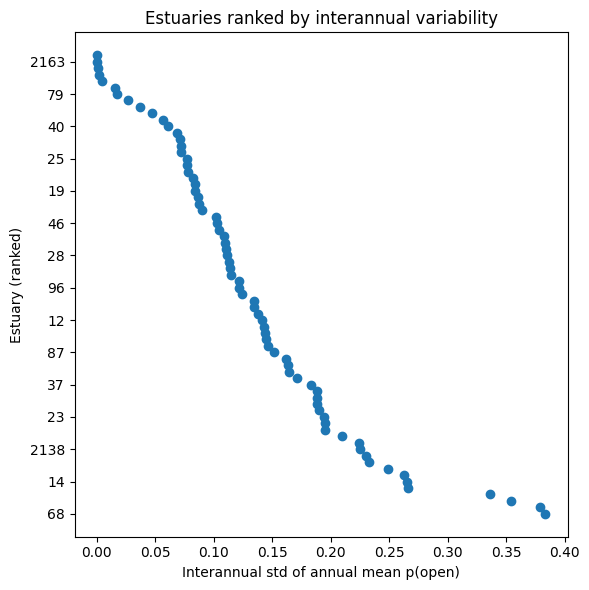

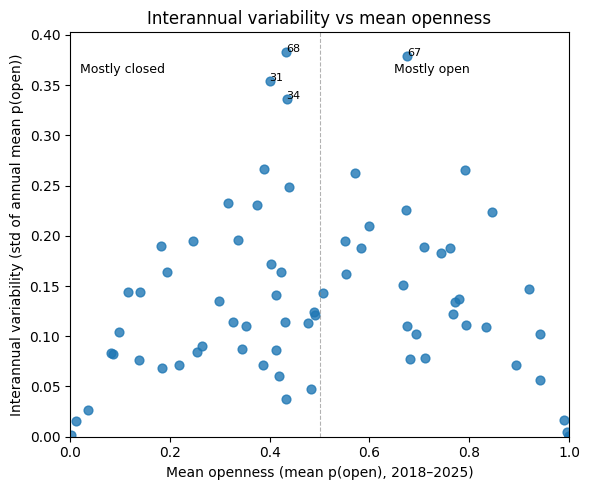

In [30]:
prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])
prob["year"] = prob["date"].dt.year

mean_open = prob.groupby("region")["p"].mean().rename("mean_open")
annual_mean = prob.groupby(["region", "year"])["p"].mean().reset_index()

interannual = (
    annual_mean.groupby("region")["p"]
    .agg(
        interannual_var="var",
        interannual_std="std",
        n_years="count",
    )
    .sort_values("interannual_std", ascending=False)
)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    interannual["interannual_std"].values,
    np.arange(len(interannual)),
    marker="o",
    linestyle="none",
)

ax.set_yticks(np.arange(0, len(interannual), 5))
ax.set_yticklabels(interannual.index[::5])
ax.set_xlabel("Interannual std of annual mean p(open)")
ax.set_ylabel("Estuary (ranked)")
ax.set_title("Estuaries ranked by interannual variability")

plt.tight_layout()
plt.show()

stats = pd.concat([mean_open, interannual["interannual_std"]], axis=1).dropna()

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    stats["mean_open"],
    stats["interannual_std"],
    s=40,
    alpha=0.8,
)

ax.set_xlabel("Mean openness (mean p(open), 2018–2025)")
ax.set_ylabel("Interannual variability (std of annual mean p(open))")
ax.set_title("Interannual variability vs mean openness")

ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)

ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(0.02, ax.get_ylim()[1] * 0.9, "Mostly closed", fontsize=9)
ax.text(0.65, ax.get_ylim()[1] * 0.9, "Mostly open", fontsize=9)

# label top 3 most variable estuaries
top_var = stats.sort_values("interannual_std", ascending=False).head(4)

for r, row in top_var.iterrows():
    ax.text(row["mean_open"], row["interannual_std"], r, fontsize=8)

plt.tight_layout()
plt.show()

In [31]:
gdf.set_index("region").loc[[68, 31, 34, 67]]

,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,potential_add,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,geometry
region,,,,,,,,,,,,,,,,,
68,Estero Americano,False,3036.0,Estero Americano,PMEP,Lagoonal Estuary,Central California,177.0,217.112018,3036_Estero Americano,False,None,38.297,-123.002,38.312031,-122.968302,"POLYGON ((-122.99804 38.29299, -122.99804 38.2..."
31,None,False,3104.0,Santa Ynez River,PMEP,Lagoonal Estuary,Central California,240.0,238.186385,3104_Santa Ynez River,False,None,34.692,-120.601,34.691065,-120.592956,"POLYGON ((-120.59698 34.68818, -120.59673 34.6..."
34,Arroyo Grande Creek,False,3101.0,Arroyo Grande Creek Lagoon,PMEP,Lagoonal Estuary,Central California,237.0,17.692757,3101_Arroyo Grande Creek Lagoon,False,None,35.100,-120.628,35.099899,-120.628083,"POLYGON ((-120.6255 35.09103, -120.62517 35.10..."
67,Estereo De San Antonio,False,3037.0,Estero de San Antonio,PMEP,Lagoonal Estuary,Central California,178.0,86.407162,3037_Estero de San Antonio,False,None,38.271,-122.977,38.266840,-122.960230,"POLYGON ((-122.97357 38.26606, -122.97357 38.2..."


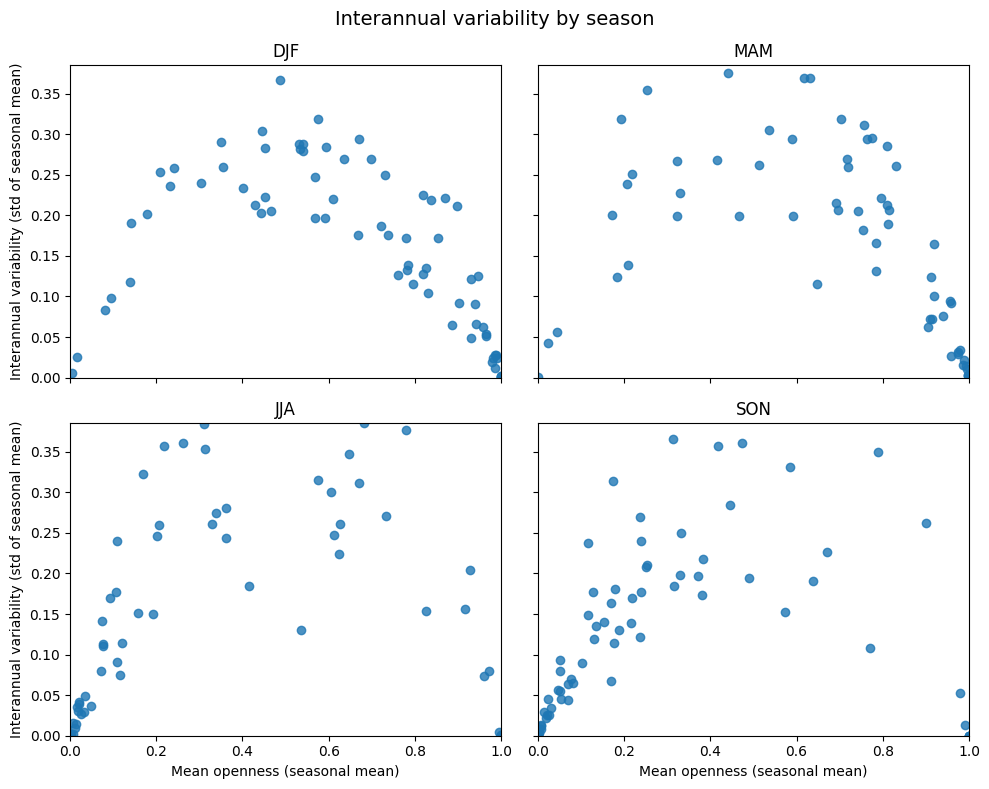

In [32]:
import numpy as np
import pandas as pd

prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])


# season label
def season_from_month(m):
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:
        return "SON"


prob["season"] = prob["date"].dt.month.map(season_from_month)

# season-year (Dec belongs to next year)
prob["season_year"] = prob["date"].dt.year
prob.loc[prob["date"].dt.month == 12, "season_year"] += 1

seasonal_mean = prob.groupby(["region", "season_year", "season"])["p"].mean().reset_index()

seasonal_var = (
    seasonal_mean.groupby(["region", "season"])["p"]
    .agg(
        interannual_std="std",
        mean_open="mean",
        n_years="count",
    )
    .reset_index()
)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
seasons = ["DJF", "MAM", "JJA", "SON"]

for ax, s in zip(axes.flat, seasons):
    sub = seasonal_var[seasonal_var["season"] == s]

    ax.scatter(sub["mean_open"], sub["interannual_std"], alpha=0.8)
    ax.set_title(s)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)

axes[0, 0].set_ylabel("Interannual variability (std of seasonal mean)")
axes[1, 0].set_ylabel("Interannual variability (std of seasonal mean)")
axes[1, 0].set_xlabel("Mean openness (seasonal mean)")
axes[1, 1].set_xlabel("Mean openness (seasonal mean)")

fig.suptitle("Interannual variability by season", fontsize=14)
plt.tight_layout()
plt.show()

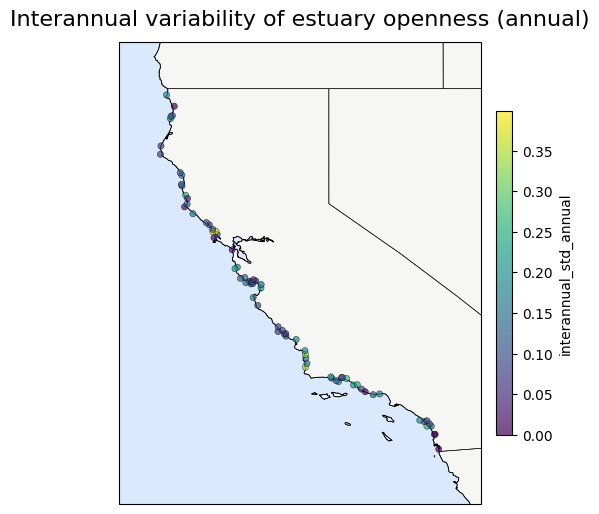

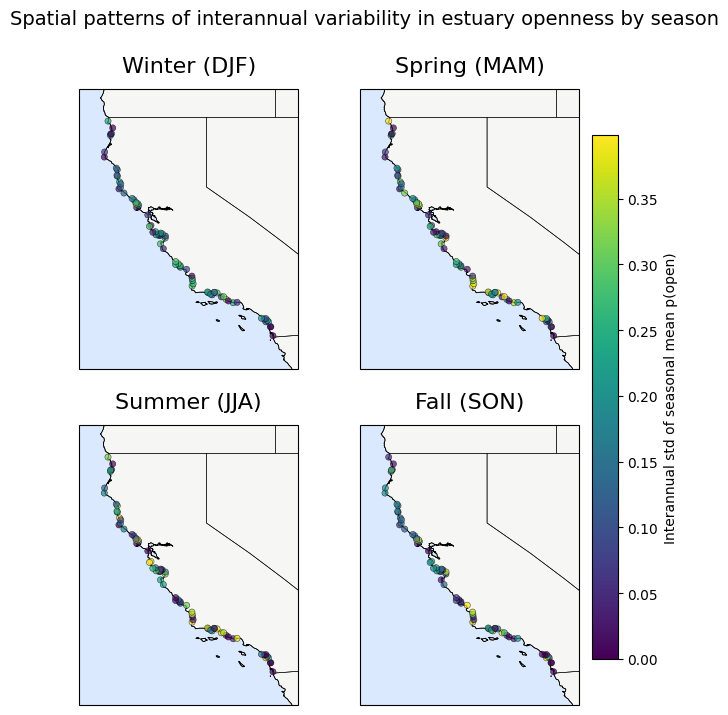

In [33]:
import numpy as np
import pandas as pd

prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])
prob["year"] = prob["date"].dt.year

# Annual mean per estuary
annual_mean = prob.groupby(["region", "year"])["p"].mean().reset_index()

# Interannual variability (std across years)
annual_var = annual_mean.groupby("region")["p"].std().rename("interannual_std_annual")


def season_from_month(m):
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:
        return "SON"


prob["season"] = prob["date"].dt.month.map(season_from_month)

# Season-year (Dec → next year)
prob["season_year"] = prob["date"].dt.year
prob.loc[prob["date"].dt.month == 12, "season_year"] += 1

seasonal_mean = prob.groupby(["region", "season_year", "season"])["p"].mean().reset_index()

seasonal_var = (
    seasonal_mean.groupby(["region", "season"])["p"].std().rename("interannual_std").reset_index()
)

gdf = gdf_points.copy().set_index("region")

# Annual
gdf["interannual_std_annual"] = annual_var

# Seasonal
for s in ["DJF", "MAM", "JJA", "SON"]:
    gdf[f"interannual_std_{s}"] = seasonal_var.loc[seasonal_var["season"] == s].set_index("region")[
        "interannual_std"
    ]

cols = [
    "interannual_std_annual",
    "interannual_std_DJF",
    "interannual_std_MAM",
    "interannual_std_JJA",
    "interannual_std_SON",
]

vmax = np.nanpercentile(gdf[cols].to_numpy(), 95)
vmin = 0.0

plot_estuaries_ca(
    gdf,
    column="interannual_std_annual",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    point_alpha=0.7,
    jitter_deg=0.05,
    markersize=20,
    title="Interannual variability of estuary openness (annual)",
    # save_path=SAVE_DIR / "interannual_variability_annual.png",
    show=True,
)

# for s in ["DJF", "MAM", "JJA", "SON"]:
#     plot_estuaries_ca(
#         gdf,
#         column=f"interannual_std_{s}",
#         cmap="viridis",
#         vmin=vmin,
#         vmax=vmax,
#         point_alpha=0.7,
#         jitter_deg=0.05,
#         markersize=20,
#         title=f"Interannual variability of estuary openness ({s})",
#         # save_path=SAVE_DIR / f"interannual_variability_{s}.png",
#         show=True,
#     )

import cartopy.crs as ccrs
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

seasons = ["DJF", "MAM", "JJA", "SON"]
titles = {
    "DJF": "Winter (DJF)",
    "MAM": "Spring (MAM)",
    "JJA": "Summer (JJA)",
    "SON": "Fall (SON)",
}

fig, axs = plt.subplots(
    2,
    2,
    figsize=(8, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for ax, s in zip(axs.flatten(), seasons):
    plot_estuaries_ca(
        gdf,
        column=f"interannual_std_{s}",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        point_alpha=0.7,
        jitter_deg=0.05,
        markersize=20,
        title=titles[s],
        add_colorbar=False,  # IMPORTANT: no per-panel colorbars
        ax=ax,  # draw on provided axis
    )

# ---- Shared colorbar ----
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(norm=norm, cmap=plt.get_cmap("viridis"))
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axs.ravel().tolist(),
    shrink=0.85,
    pad=0.02,
)
cbar.set_label("Interannual std of seasonal mean p(open)")

fig.suptitle(
    "Spatial patterns of interannual variability in estuary openness by season",
    fontsize=14,
    y=0.98,
)
plt.show()

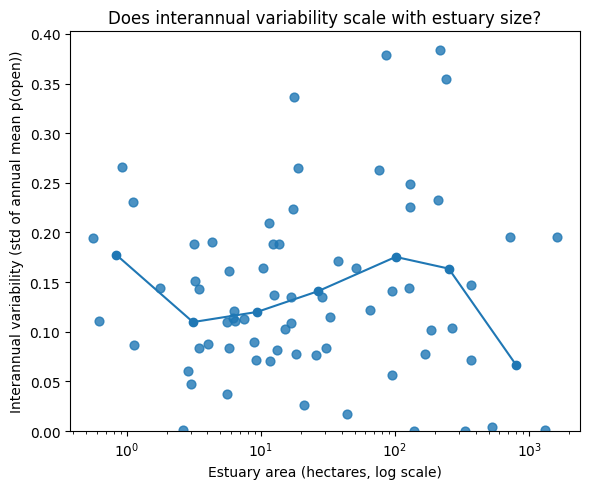

In [34]:
x = gdf["Estuary_Hectares"].astype(float)
y = gdf["interannual_std_annual"].astype(float)

m = np.isfinite(x) & np.isfinite(y) & (x > 0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x[m], y[m], alpha=0.8, s=40)

ax.set_xscale("log")
ax.set_xlabel("Estuary area (hectares, log scale)")
ax.set_ylabel("Interannual variability (std of annual mean p(open))")
ax.set_title("Does interannual variability scale with estuary size?")
ax.set_ylim(bottom=0)

plt.tight_layout()
# plt.show()

xb = x[m].to_numpy()
yb = y[m].to_numpy()

# log-bins
bins = np.logspace(np.log10(xb.min()), np.log10(xb.max()), 8)
bin_id = np.digitize(xb, bins) - 1

bin_x = []
bin_y = []
for k in range(len(bins) - 1):
    sel = bin_id == k
    if sel.sum() >= 3:
        bin_x.append(np.exp(np.mean(np.log(xb[sel]))))  # geometric mean x
        bin_y.append(np.mean(yb[sel]))

ax.plot(bin_x, bin_y, marker="o")
plt.show()

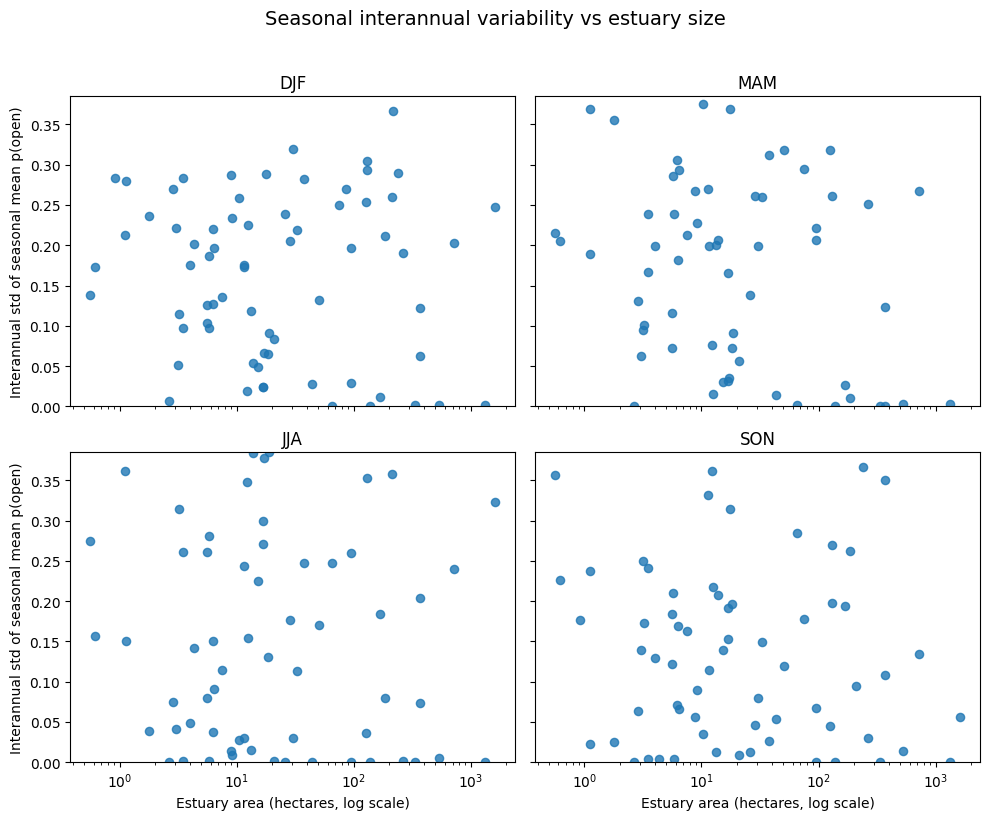

In [35]:
seasons = ["DJF", "MAM", "JJA", "SON"]
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axs = axs.flatten()

x = gdf["Estuary_Hectares"].astype(float)

for ax, s in zip(axs, seasons):
    y = gdf[f"interannual_std_{s}"].astype(float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0)

    ax.scatter(x[m], y[m], alpha=0.8, s=35)
    ax.set_title(s)
    ax.set_xscale("log")
    ax.set_ylim(bottom=0)

axs[2].set_xlabel("Estuary area (hectares, log scale)")
axs[3].set_xlabel("Estuary area (hectares, log scale)")
axs[0].set_ylabel("Interannual std of seasonal mean p(open)")
axs[2].set_ylabel("Interannual std of seasonal mean p(open)")

fig.suptitle("Seasonal interannual variability vs estuary size", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

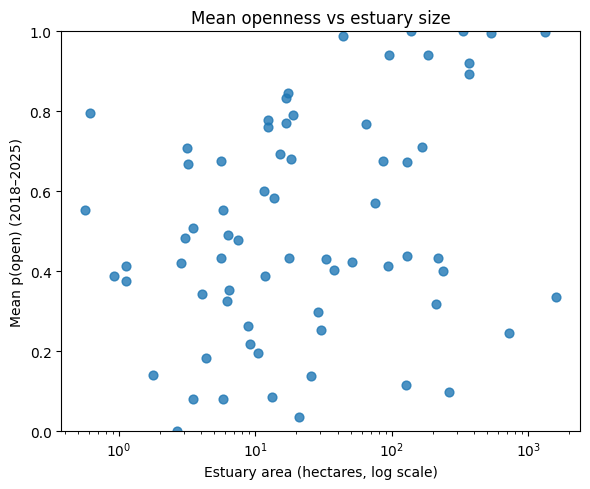

In [36]:
# mean openness across all days
prob = full["y_prob"].rename("p").reset_index()
mean_open = prob.groupby("region")["p"].mean()

gdf["mean_open"] = mean_open

x = gdf["Estuary_Hectares"].astype(float)
y = gdf["mean_open"].astype(float)
m = np.isfinite(x) & np.isfinite(y) & (x > 0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x[m], y[m], alpha=0.8, s=40)
ax.set_xscale("log")
ax.set_xlabel("Estuary area (hectares, log scale)")
ax.set_ylabel("Mean p(open) (2018–2025)")
ax.set_title("Mean openness vs estuary size")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

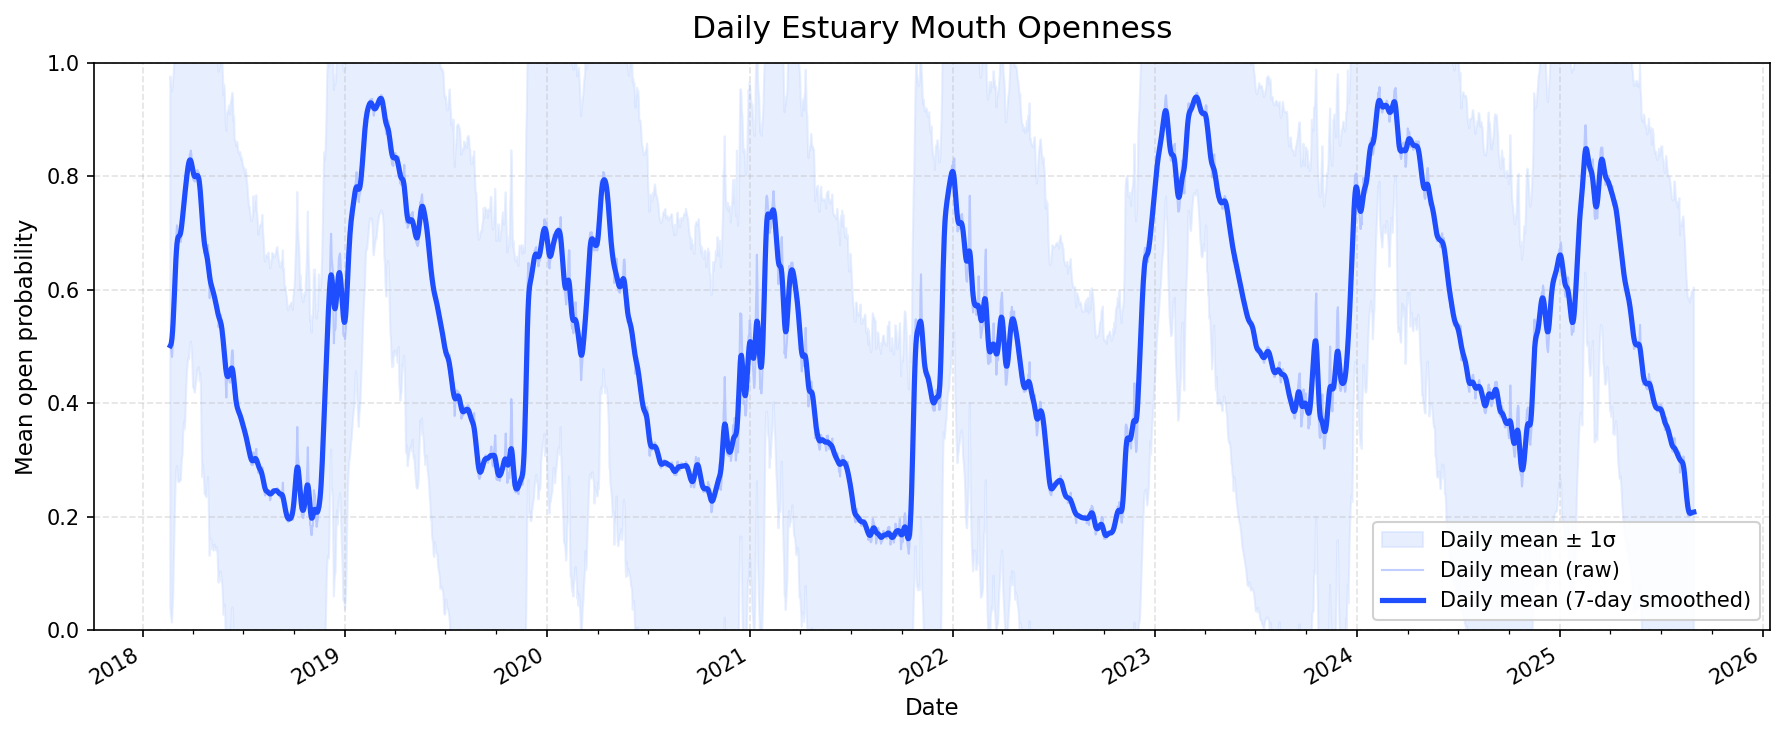

In [37]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# ---------------------------------------------------------
# 1. Prepare daily mean / std from y_mat_prob
# ---------------------------------------------------------
# date_axis: sequence of daily dates aligned with columns of y_mat_prob
dates = pd.to_datetime(date_axis)
assert y_mat_prob.shape[1] == len(dates), "y_mat_prob and date_axis length mismatch"

# Mean and std across regions for each day
daily_mean = y_mat_prob.mean(axis=0)  # shape (n_days,)
daily_std = y_mat_prob.std(axis=0)  # optional shading

# ---------------------------------------------------------
# 2. Smooth with ~7-day Gaussian window
# ---------------------------------------------------------
# Gaussian sigma is in “index units”; sigma≈3 gives you a ~7-day FWHM-ish window.
sigma = 3  # ~weekly smoothing
daily_mean_smooth = gaussian_filter1d(daily_mean, sigma=sigma)

# ---------------------------------------------------------
# 3. Prepare storm events
# ---------------------------------------------------------
# storm_events = storm_events.copy()
# storm_events["date_start"] = pd.to_datetime(storm_events["date_start"])
# storm_events["date_end"]   = pd.to_datetime(storm_events["date_end"])

# # If they are tz-aware, drop the timezone
# if storm_events["date_start"].dt.tz is not None:
#     storm_events["date_start"] = storm_events["date_start"].dt.tz_convert(None)
#     storm_events["date_end"]   = storm_events["date_end"].dt.tz_convert(None)

plot_start = pd.to_datetime(dates.min())
plot_end = pd.to_datetime(dates.max())

# storm_mask = (storm_events["date_start"] >= plot_start) & (storm_events["date_start"] <= plot_end)
# storm_events_plot = storm_events[storm_mask].sort_values("date_start")

# ---------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

# Shaded ±1 std dev band (raw daily variability)
ax.fill_between(
    dates,
    daily_mean - daily_std,
    daily_mean + daily_std,
    color="#c5d8ff",
    alpha=0.4,
    label="Daily mean ± 1σ",
)

# Raw daily mean (thin, light)
ax.plot(
    dates,
    daily_mean,
    color="#a6b9ff",
    linewidth=1.0,
    alpha=0.7,
    label="Daily mean (raw)",
)

# Smoothed daily mean (thick, on top)
ax.plot(
    dates,
    daily_mean_smooth,
    color="#1f4eff",
    linewidth=2.5,
    label="Daily mean (7-day smoothed)",
)

# # ---------------------------------------------------------
# # 5. Overlay storm dates
# # ---------------------------------------------------------
# first_line = True
# for _, row in storm_events_plot.iterrows():
#     d = row["date_start"]
#     ax.axvline(
#         d,
#         color="#d62728",
#         linestyle="--",
#         linewidth=1.2,
#         alpha=0.7,
#         label="Major storm" if first_line else None,
#     )
#     first_line = False

# ---------------------------------------------------------
# 6. Cosmetics & formatting
# ---------------------------------------------------------
ax.set_ylabel("Mean open probability", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.set_title("Daily Estuary Mouth Openness", fontsize=15, pad=12)

ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.35)

# Date formatting on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#cccccc",
)

plt.tight_layout()
# plt.savefig(FIG_DIR / "daily_open_pct.png")
plt.show()

             std       var  n_years
season                             
DJF     0.090744  0.008234        8
MAM     0.142376  0.020271        8
JJA     0.105004  0.011026        8
SON     0.070635  0.004989        7


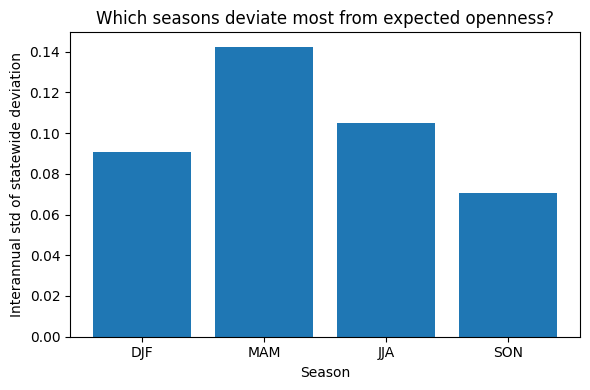

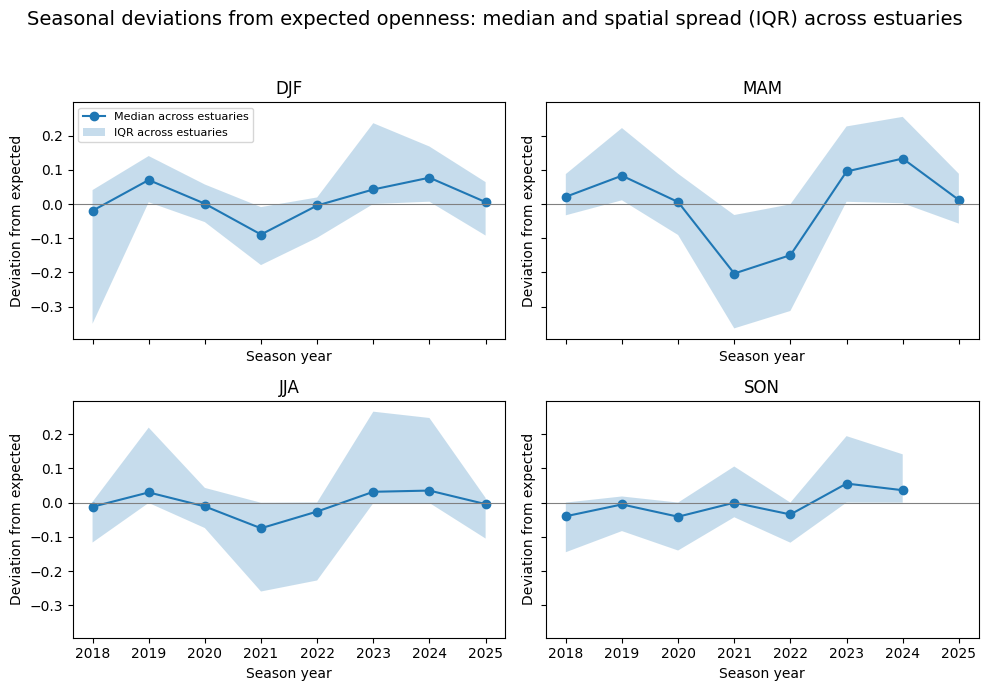

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# daily probabilities
prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])


def season_from_month(m: int) -> str:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:
        return "SON"


prob["season"] = prob["date"].dt.month.map(season_from_month)

# season-year: Dec counts toward next year's DJF
prob["season_year"] = prob["date"].dt.year
prob.loc[prob["date"].dt.month == 12, "season_year"] += 1

# 1) mean p(open) per (region, season_year, season)
rys = prob.groupby(["region", "season_year", "season"])["p"].mean().reset_index(name="p_mean")

# 2) expected seasonal mean per (region, season) across years
mu = rys.groupby(["region", "season"])["p_mean"].mean().rename("mu").reset_index()

# 3) join expected back and compute deviation
rys = rys.merge(mu, on=["region", "season"], how="left")
rys["delta"] = rys["p_mean"] - rys["mu"]

# 4) aggregate across regions -> statewide mean deviation per (season_year, season)
state = rys.groupby(["season_year", "season"])["delta"].mean().reset_index()

# 5) for each season: interannual variability of statewide deviation
season_var = (
    state.groupby("season")["delta"]
    .agg(std="std", var="var", n_years="count")
    .reindex(["DJF", "MAM", "JJA", "SON"])
)

print(season_var)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(season_var.index, season_var["std"])
ax.set_ylabel("Interannual std of statewide deviation")
ax.set_xlabel("Season")
ax.set_title("Which seasons deviate most from expected openness?")

plt.tight_layout()
plt.show()

state_spread_robust = (
    rys.groupby(["season_year", "season"])["delta"]
    .agg(
        median=lambda x: np.nanmedian(x),
        q25=lambda x: np.nanpercentile(x, 25),
        q75=lambda x: np.nanpercentile(x, 75),
        n_regions="count",
    )
    .reset_index()
)

pivot_med = state_spread_robust.pivot(
    index="season_year", columns="season", values="median"
).reindex(columns=["DJF", "MAM", "JJA", "SON"])

pivot_q25 = state_spread_robust.pivot(index="season_year", columns="season", values="q25").reindex(
    columns=["DJF", "MAM", "JJA", "SON"]
)

pivot_q75 = state_spread_robust.pivot(index="season_year", columns="season", values="q75").reindex(
    columns=["DJF", "MAM", "JJA", "SON"]
)

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axs = axs.flatten()
seasons = ["DJF", "MAM", "JJA", "SON"]

for ax, s in zip(axs, seasons):
    med = pivot_med[s]
    q25 = pivot_q25[s]
    q75 = pivot_q75[s]

    ax.plot(
        pivot_med.index,
        med,
        marker="o",
        linewidth=1.5,
        label="Median across estuaries",
    )

    ax.fill_between(
        pivot_med.index,
        q25,
        q75,
        alpha=0.25,
        label="IQR across estuaries",
    )

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(s)
    ax.set_xlabel("Season year")
    ax.set_ylabel("Deviation from expected")

axs[0].legend(loc="upper left", fontsize=8)

fig.suptitle(
    "Seasonal deviations from expected openness: median and spatial spread (IQR) across estuaries",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

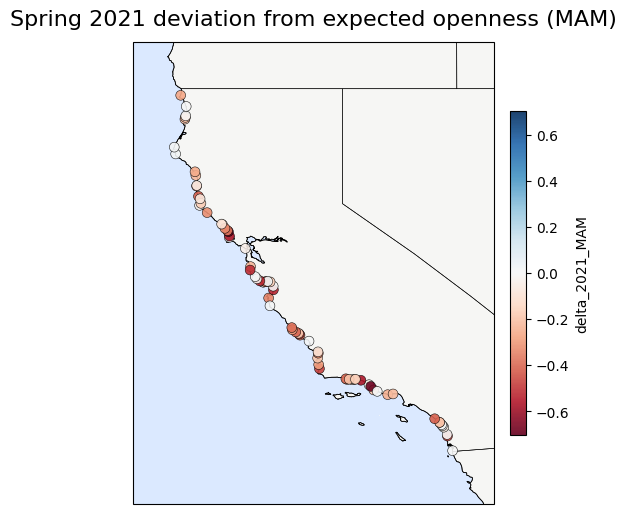

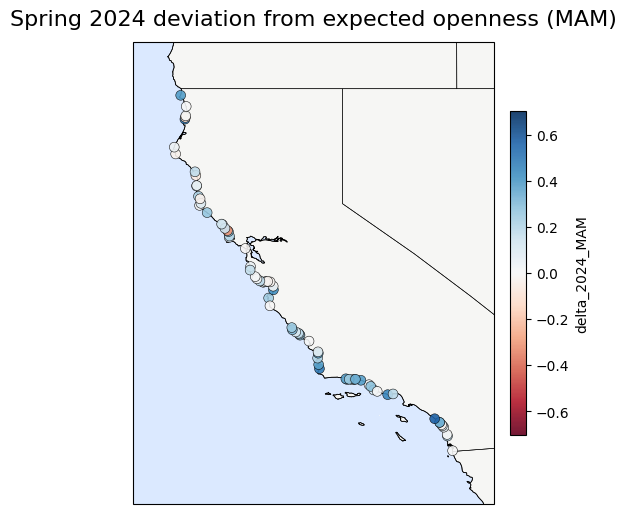

In [39]:
# Select specific season-years
sel = rys[
    ((rys["season_year"] == 2021) & (rys["season"] == "MAM"))
    | ((rys["season_year"] == 2024) & (rys["season"] == "MAM"))
].copy()

# Pivot so each region has its delta for each case
delta_2021_MAM = (
    sel[(sel["season_year"] == 2021) & (sel["season"] == "MAM")]
    .set_index("region")["delta"]
    .rename("delta_2021_MAM")
)

delta_2024_MAM = (
    sel[(sel["season_year"] == 2024) & (sel["season"] == "MAM")]
    .set_index("region")["delta"]
    .rename("delta_2024_MAM")
)

gdf = gdf_points.copy().set_index("region")

gdf["delta_2021_MAM"] = delta_2021_MAM
gdf["delta_2024_MAM"] = delta_2024_MAM

import numpy as np

vmax = np.nanmax(np.abs(gdf[["delta_2021_MAM", "delta_2024_MAM"]].to_numpy()))
vmin = -vmax

plot_estuaries_ca(
    gdf,
    column="delta_2021_MAM",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax,
    title="Spring 2021 deviation from expected openness (MAM)",
    # save_path=SAVE_DIR / "delta_2021_MAM_map.png",
    show=True,
)

plot_estuaries_ca(
    gdf,
    column="delta_2024_MAM",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax,
    title="Spring 2024 deviation from expected openness (MAM)",
    # save_path=SAVE_DIR / "delta_2024_MAM_map.png",
    show=True,
)

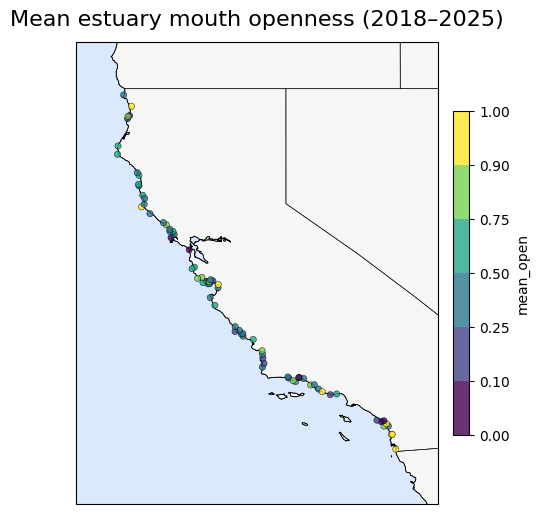

In [40]:
import pandas as pd

prob = full["y_prob"].rename("p").reset_index()

mean_open = prob.groupby("region")["p"].mean().rename("mean_open")

gdf = gdf_points.copy().set_index("region")

gdf["mean_open"] = mean_open

bins = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

plot_estuaries_ca(
    gdf,
    column="mean_open",
    cmap="viridis",
    bins=bins,
    markersize=20,
    point_alpha=0.8,
    jitter_deg=0.05,
    title="Mean estuary mouth openness (2018–2025)",
)

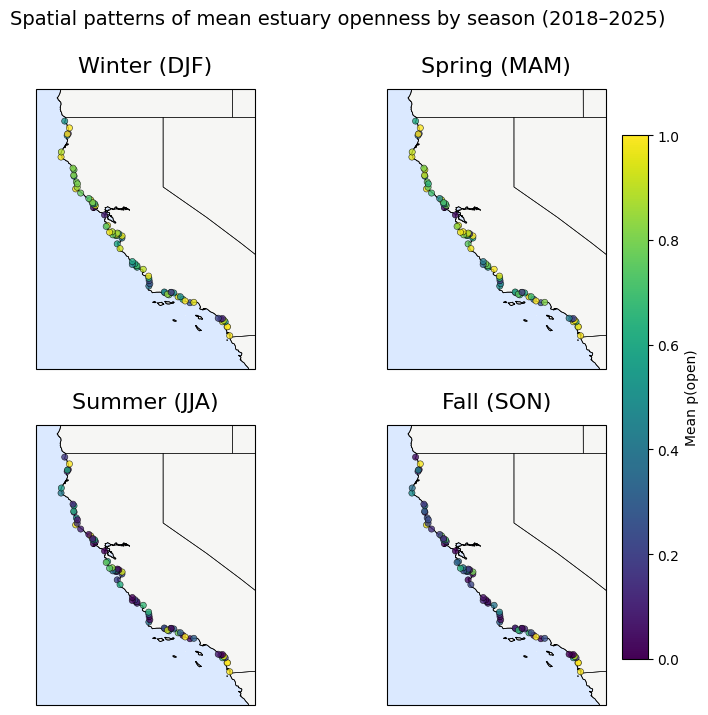

In [41]:
import numpy as np
import pandas as pd

prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])


def season_from_month(m: int) -> str:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:
        return "SON"


prob["season"] = prob["date"].dt.month.map(season_from_month)

# mean p(open) per region, per season across all years
season_mean = (
    prob.groupby(["region", "season"])["p"]
    .mean()
    .unstack("season")
    .reindex(columns=["DJF", "MAM", "JJA", "SON"])
)

gdf = gdf_points.copy().set_index("region").join(season_mean, how="left")

import cartopy.crs as ccrs
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from estuary.util.plotting import plot_estuaries_ca

seasons = ["DJF", "MAM", "JJA", "SON"]
titles = {"DJF": "Winter (DJF)", "MAM": "Spring (MAM)", "JJA": "Summer (JJA)", "SON": "Fall (SON)"}

cmap = "viridis"
vmin, vmax = 0.0, 1.0

fig, axs = plt.subplots(
    2,
    2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for ax, s in zip(axs.flatten(), seasons):
    plot_estuaries_ca(
        gdf,
        column=s,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        title=titles[s],
        markersize=20,
        point_alpha=0.8,
        jitter_deg=0.05,
        add_colorbar=False,  # no per-panel colorbar
        show_labels=False,
        ax=ax,  # <- key: draw on provided axis; no save/show inside
    )

# Shared colorbar
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(norm=norm, cmap=plt.get_cmap(cmap))
sm.set_array([])

cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), shrink=0.85, pad=0.02)
cbar.set_label("Mean p(open)")

fig.suptitle("Spatial patterns of mean estuary openness by season (2018–2025)", fontsize=14, y=0.98)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

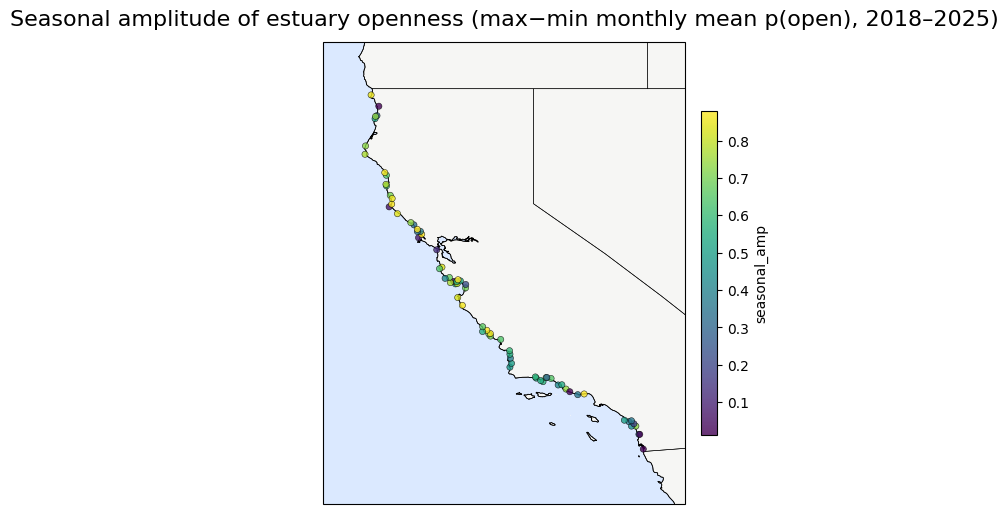

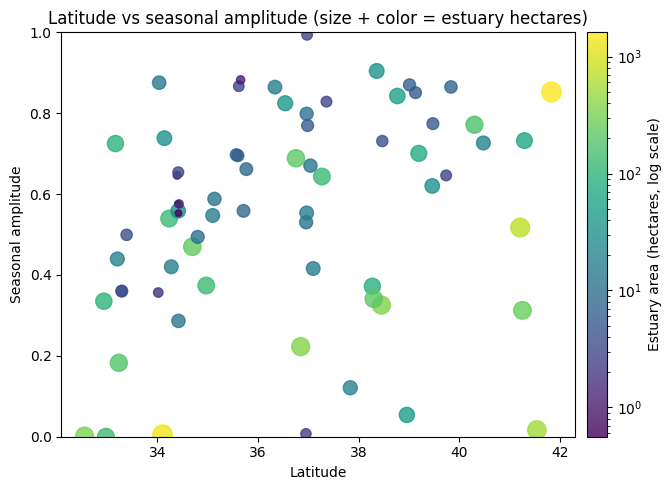

In [46]:
import numpy as np
import pandas as pd

prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])
prob["month"] = prob["date"].dt.month

# month-of-year mean per estuary
moy = prob.groupby(["region", "month"])["p"].mean().unstack("month").reindex(columns=range(1, 13))

seasonal_amp = (moy.max(axis=1) - moy.min(axis=1)).rename("seasonal_amp")
seasonal_amp.describe()

gdf = gdf_points.copy().set_index("region")
gdf["seasonal_amp"] = seasonal_amp

vmax_amp = float(np.nanpercentile(gdf["seasonal_amp"], 95))
vmin_amp = float(np.nanpercentile(gdf["seasonal_amp"], 5))
# plot_estuaries_ca(gdf, "seasonal_amp", cmap="viridis", vmin=0.0, vmax=vmax_amp, title="Seasonal amplitude (clipped)", show=True)

plot_estuaries_ca(
    gdf,
    column="seasonal_amp",
    cmap="viridis",
    vmin=vmin_amp,
    vmax=vmax_amp,
    markersize=20,
    point_alpha=0.8,
    jitter_deg=0.05,
    title="Seasonal amplitude of estuary openness (max−min monthly mean p(open), 2018–2025)",
    # save_path=SAVE_DIR / "seasonal_amplitude_map.png",
    show=True,
)

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

gdf_lat = gdf.copy()
gdf_lat["lat"] = gdf_lat.geometry.y
x = gdf_lat["lat"].astype(float)
y = gdf_lat["seasonal_amp"].astype(float)
h = gdf_lat["Estuary_Hectares"].astype(float)

m = np.isfinite(x) & np.isfinite(y) & np.isfinite(h) & (h > 0)

fig, ax = plt.subplots(figsize=(7, 5))

norm = mcolors.LogNorm(vmin=h[m].min(), vmax=h[m].max())

logh = np.log10(h[m])
logh = (logh - logh.min()) / (logh.max() - logh.min() + 1e-9)
sizes = 20 + 180 * logh

sc = ax.scatter(
    x[m],
    y[m],
    c=h[m],
    norm=norm,
    s=sizes,
    alpha=0.8,
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Estuary area (hectares, log scale)")

ax.set_xlabel("Latitude")
ax.set_ylabel("Seasonal amplitude")
ax.set_title("Latitude vs seasonal amplitude (size + color = estuary hectares)")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

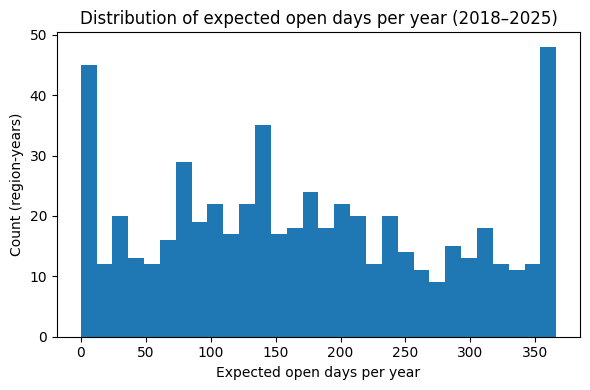

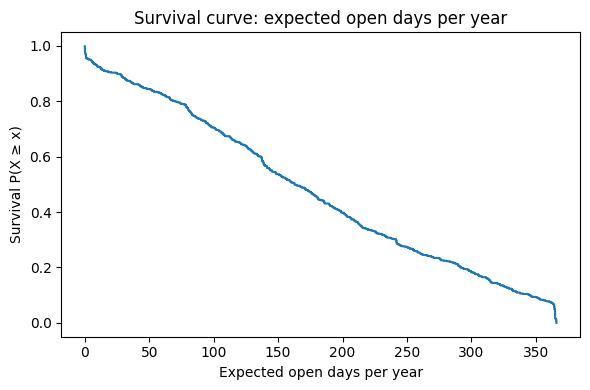

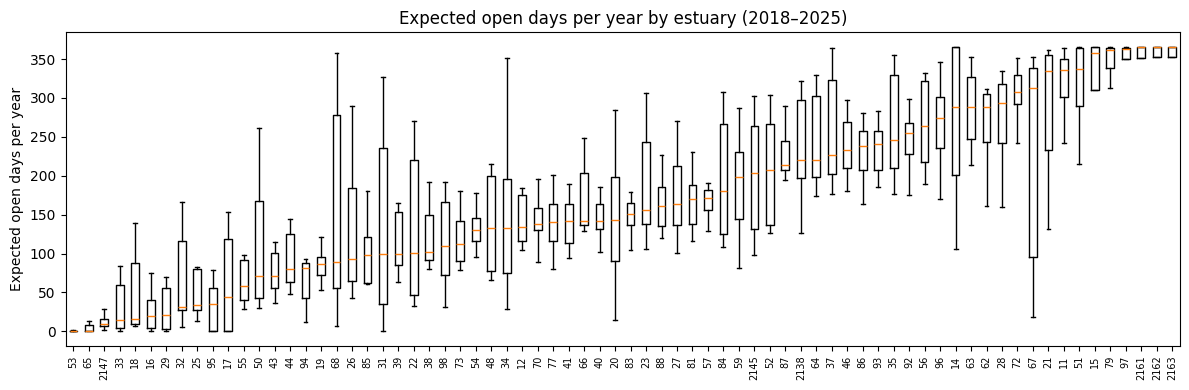

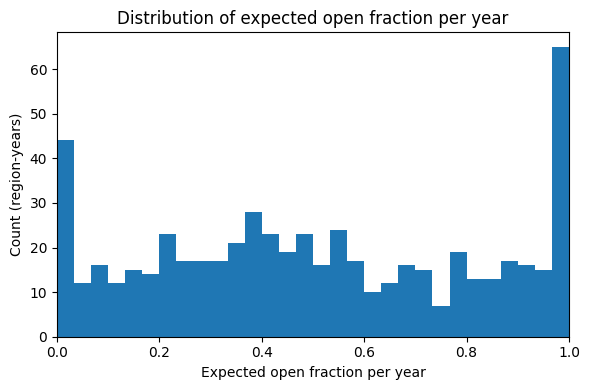

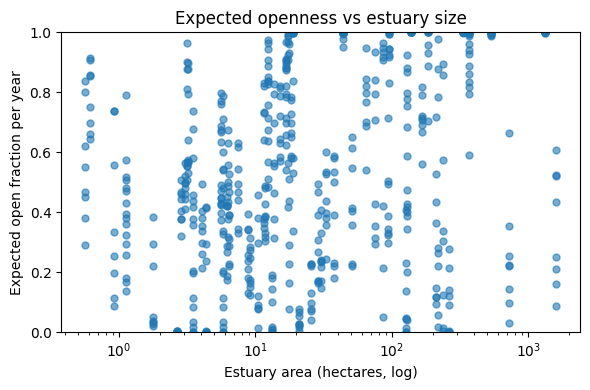

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])
prob["year"] = prob["date"].dt.year

open_days_year = (
    prob.groupby(["region", "year"])["p"].sum().rename("expected_open_days").reset_index()
)

open_days_year["expected_closed_days"] = 365.0 - open_days_year["expected_open_days"]

vals = open_days_year["expected_open_days"].to_numpy()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vals, bins=30)
ax.set_xlabel("Expected open days per year")
ax.set_ylabel("Count (region-years)")
ax.set_title("Distribution of expected open days per year (2018–2025)")
plt.tight_layout()
plt.show()

x = np.sort(vals)
surv = 1.0 - np.arange(1, len(x) + 1) / len(x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.step(x, surv, where="post")
ax.set_xlabel("Expected open days per year")
ax.set_ylabel("Survival P(X ≥ x)")
ax.set_title("Survival curve: expected open days per year")
plt.tight_layout()
plt.show()

med = open_days_year.groupby("region")["expected_open_days"].median().sort_values()
regions_order = med.index.tolist()
data = [
    open_days_year.loc[open_days_year["region"] == r, "expected_open_days"].to_numpy()
    for r in regions_order
]
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(data, showfliers=False)

ax.set_ylabel("Expected open days per year")
ax.set_title("Expected open days per year by estuary (2018–2025)")

# reduce x tick clutter
step = 1
ax.set_xticks(np.arange(1, len(regions_order) + 1, step))
ax.set_xticklabels(
    [regions_order[i - 1] for i in range(1, len(regions_order) + 1, step)], rotation=90, fontsize=7
)

plt.tight_layout()
plt.show()

days_in_year = prob.groupby(["region", "year"])["date"].nunique().rename("n_days").reset_index()

tmp = open_days_year.merge(days_in_year, on=["region", "year"], how="left")
tmp["expected_open_frac"] = tmp["expected_open_days"] / tmp["n_days"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(tmp["expected_open_frac"], bins=30)
ax.set_xlabel("Expected open fraction per year")
ax.set_ylabel("Count (region-years)")
ax.set_title("Distribution of expected open fraction per year")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

x = tmp2["Estuary_Hectares"].astype(float)
y = tmp2["expected_open_frac"].astype(float)
m = np.isfinite(x) & np.isfinite(y) & (x > 0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x[m], y[m], alpha=0.6, s=25)
ax.set_xscale("log")
ax.set_xlabel("Estuary area (hectares, log)")
ax.set_ylabel("Expected open fraction per year")
ax.set_title("Expected openness vs estuary size")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [91]:
gdf_points[gdf_points.region.isin(rho1_w[rho1_w < 0.6].index)]

,region,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,potential_add,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,geometry,lat,lon
9,2162,San Dieguito Lagoon,False,4055.0,San Dieguito Lagoon,PMEP,Embayment/Bay,Southern California Bight,298.0,137.537587,4055_San Dieguito Lagoon,False,SC-SDL,32.975140,-117.268779,32.971848,-117.253007,POINT (-117.26904 32.97553),32.975531,-117.269045
48,53,Younder Lagoon,False,3069.0,Younger Lagoon,PMEP,Lagoonal Estuary,Central California,205.0,2.641736,3069_Younger Lagoon,False,None,36.949000,-122.067000,36.950680,-122.066655,POINT (-122.06715 36.94974),36.949739,-122.067148
60,65,Abbots Lagoon,False,NaN,None,None,None,None,NaN,NaN,None,False,None,38.119000,-122.957000,NaN,NaN,POINT (-122.95739 38.11792),38.117919,-122.957390
71,79,Garcia River,False,3029.0,Garcia River,PMEP,Riverine Estuary,Central California,170.0,43.674593,3029_Garcia River,False,None,38.954000,-123.733000,38.947512,-123.729298,POINT (-123.73134 38.95454),38.954536,-123.731336
87,97,Klamath River,False,2094.0,Klamath River,PMEP,Riverine Estuary,"Washington, Oregon, Northern California Coast",127.0,531.844110,2094_Klamath River,False,None,41.543000,-124.080000,41.526432,-124.043925,POINT (-124.07938 41.53788),41.537880,-124.079384
91,2161,Mugu Lagoon,False,4016.0,Mugu Lagoon,PMEP,Riverine Estuary,Southern California Bight,260.0,1321.687643,4016_Mugu Lagoon,False,SC-MUGU,34.100557,-119.094070,34.105028,-119.117633,POINT (-119.09335 34.10098),34.100980,-119.093346
92,2163,Tijuana River Estuary,False,4060.0,Tijuana River,PMEP,Riverine Estuary,Southern California Bight,303.0,332.387999,4060_Tijuana River,False,SC-TJES,32.555798,-117.127163,32.555755,-117.122579,POINT (-117.12679 32.55233),32.552333,-117.126795


P_w shape: (72, 393)
low var sites: 8 / 72
P_w_f shape: (64, 393)


,tv_mean_abs_weekly_change,frac_mid_0p3_0p7_weekly,lag1_autocorr_weekly,persistence_tau_weeks
count,64.000000,64.000000,64.000000,64.000000
mean,0.087093,0.096692,0.874275,9.835918
std,0.033127,0.057950,0.058480,5.307592
min,0.022509,0.017812,0.624337,2.661960
25%,0.062165,0.048346,0.849626,6.650092
50%,0.092580,0.089059,0.886951,8.845764
75%,0.108024,0.132316,0.910973,11.233866
max,0.179546,0.279898,0.968111,31.359112


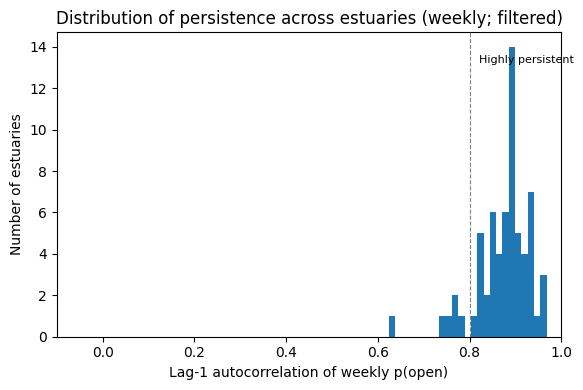

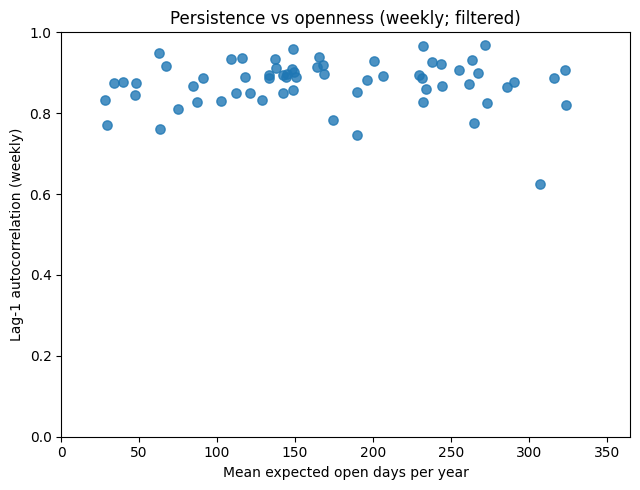

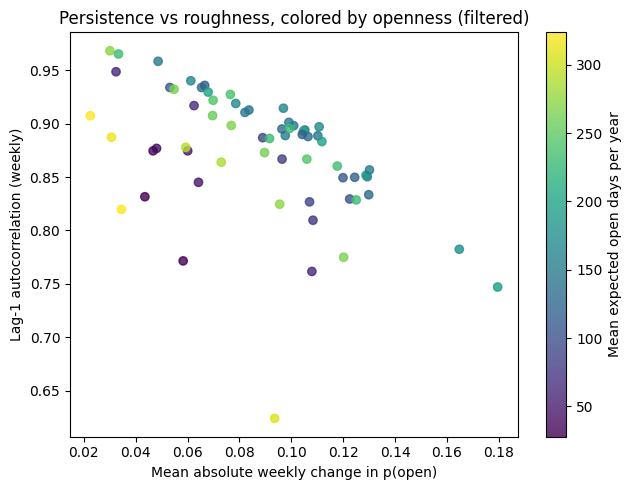

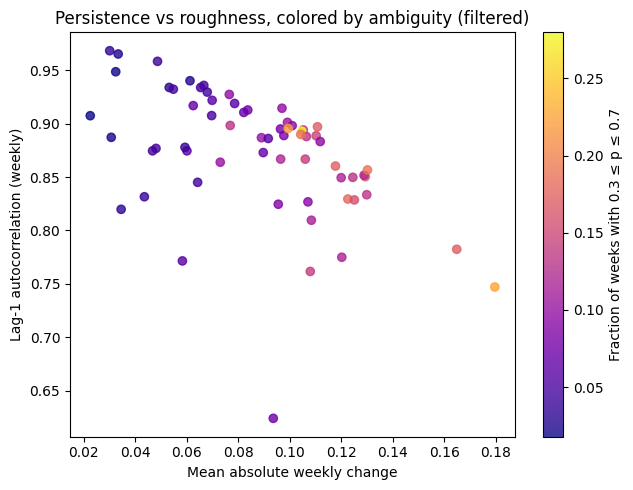

In [106]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# Weekly aggregation
# -----------------------------
prob = full["y_prob"].rename("p").reset_index()
prob["date"] = pd.to_datetime(prob["date"])

weekly = prob.set_index("date").groupby("region")["p"].resample("W-SUN").mean().reset_index()

P_w = weekly.pivot(index="region", columns="date", values="p").astype(float)

print("P_w shape:", P_w.shape)  # ~72 × ~365 weeks

# -----------------------------
# Filter low-variability sites (Option A)
# -----------------------------
var_w = P_w.var(axis=1)
flat_sites = var_w < 1e-2  # tune if needed

print("low var sites:", int(flat_sites.sum()), "/", len(flat_sites))

P_w_f = P_w.loc[~flat_sites].copy()
print("P_w_f shape:", P_w_f.shape)

# -----------------------------
# Switching metrics (weekly) on filtered sites
# -----------------------------
dp_w = P_w_f.diff(axis=1).abs()
tv_w = dp_w.mean(axis=1).rename("tv_mean_abs_weekly_change")

mid_min, mid_max = 0.3, 0.7
mid_w = ((P_w_f >= mid_min) & (P_w_f <= mid_max)).mean(axis=1).rename("frac_mid_0p3_0p7_weekly")


def lag1_autocorr_weekly(row: pd.Series) -> float:
    x = row.to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan
    x0, x1 = x[:-1], x[1:]
    if np.std(x0) == 0 or np.std(x1) == 0:
        return np.nan
    return float(np.corrcoef(x0, x1)[0, 1])


rho1_w = P_w_f.apply(lag1_autocorr_weekly, axis=1).rename("lag1_autocorr_weekly")
tau_w = (1.0 / (1.0 - rho1_w.clip(upper=0.999))).rename("persistence_tau_weeks")

switch_metrics_w = pd.concat([tv_w, mid_w, rho1_w, tau_w], axis=1)
display(switch_metrics_w.describe())

# -----------------------------
# Plots
# -----------------------------

# 1) Histogram of lag-1 autocorr (filtered)
vals = rho1_w.dropna().to_numpy()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vals, bins=25)
ax.set_xlabel("Lag-1 autocorrelation of weekly p(open)")
ax.set_ylabel("Number of estuaries")
ax.set_title("Distribution of persistence across estuaries (weekly; filtered)")
ax.set_xlim(-0.1, 1.0)
ax.axvline(0.8, color="gray", linestyle="--", linewidth=0.8)
ax.text(0.82, ax.get_ylim()[1] * 0.9, "Highly persistent", fontsize=8)
plt.tight_layout()
plt.show()

# 2) Persistence vs openness (weekly; filtered)
# mean_open_days should be a Series indexed by region with mean_expected_open_days
df_scatter_w = (
    pd.concat([mean_open_days, rho1_w], axis=1)
    .rename(columns={0: "mean_expected_open_days"})  # only needed if your Series lacks a name
    .dropna()
)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(
    df_scatter_w["mean_expected_open_days"],
    df_scatter_w["lag1_autocorr_weekly"],
    alpha=0.8,
    s=45,
)
ax.set_xlabel("Mean expected open days per year")
ax.set_ylabel("Lag-1 autocorrelation (weekly)")
ax.set_title("Persistence vs openness (weekly; filtered)")
ax.set_xlim(0, 365)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

# 3) Persistence vs roughness, colored by openness (filtered)
mean_open_days_f = mean_open_days.loc[rho1_w.index]

fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(
    tv_w,
    rho1_w,
    c=mean_open_days_f,
    cmap="viridis",
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mean expected open days per year")
ax.set_xlabel("Mean absolute weekly change in p(open)")
ax.set_ylabel("Lag-1 autocorrelation (weekly)")
ax.set_title("Persistence vs roughness, colored by openness (filtered)")
plt.tight_layout()
plt.show()

# 4) Persistence vs roughness, colored by ambiguity (filtered)
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(
    tv_w,
    rho1_w,
    c=mid_w,
    cmap="plasma",
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(f"Fraction of weeks with {mid_min} ≤ p ≤ {mid_max}")
ax.set_xlabel("Mean absolute weekly change")
ax.set_ylabel("Lag-1 autocorrelation (weekly)")
ax.set_title("Persistence vs roughness, colored by ambiguity (filtered)")
plt.tight_layout()
plt.show()

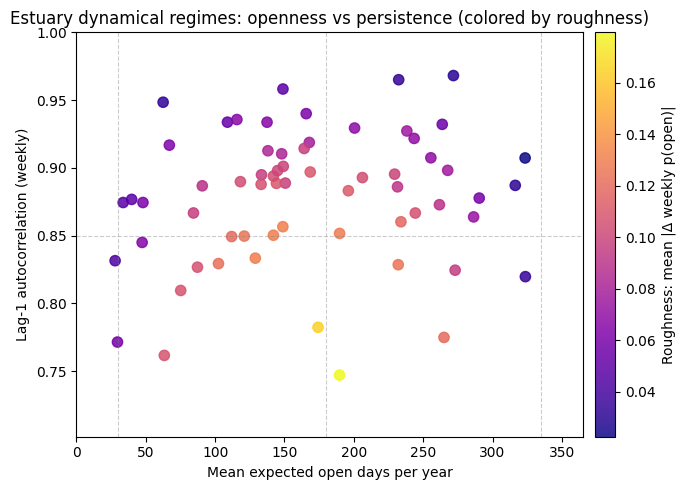

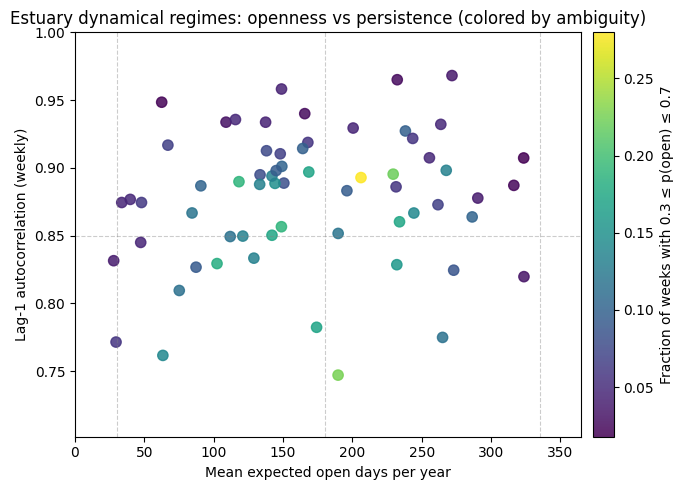

In [112]:
import pandas as pd

df_regime = pd.concat(
    [
        mean_open_days.rename("mean_expected_open_days"),
        rho1_w.rename("lag1_autocorr_weekly"),
        tv_w.rename("roughness_tv_weekly"),
        mid_w.rename("frac_mid_weekly"),
    ],
    axis=1,
).dropna()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    df_regime["mean_expected_open_days"],
    df_regime["lag1_autocorr_weekly"],
    c=df_regime["roughness_tv_weekly"],
    cmap="plasma",
    alpha=0.85,
    s=55,
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Roughness: mean |Δ weekly p(open)|")

ax.set_xlabel("Mean expected open days per year")
ax.set_ylabel("Lag-1 autocorrelation (weekly)")
ax.set_title("Estuary dynamical regimes: openness vs persistence (colored by roughness)")

ax.set_xlim(0, 365)
ax.set_ylim(df_regime["lag1_autocorr_weekly"].quantile(0.01), 1.0)

for v in [30, 180, 335]:
    ax.axvline(v, color="gray", linestyle="--", linewidth=0.8, alpha=0.4)

ax.axhline(0.85, color="gray", linestyle="--", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    df_regime["mean_expected_open_days"],
    df_regime["lag1_autocorr_weekly"],
    c=df_regime["frac_mid_weekly"],
    cmap="viridis",
    alpha=0.85,
    s=55,
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Fraction of weeks with 0.3 ≤ p(open) ≤ 0.7")

ax.set_xlabel("Mean expected open days per year")
ax.set_ylabel("Lag-1 autocorrelation (weekly)")
ax.set_title("Estuary dynamical regimes: openness vs persistence (colored by ambiguity)")

ax.set_xlim(0, 365)
ax.set_ylim(df_regime["lag1_autocorr_weekly"].quantile(0.01), 1.0)

for v in [30, 180, 335]:
    ax.axvline(v, color="gray", linestyle="--", linewidth=0.8, alpha=0.4)

ax.axhline(0.85, color="gray", linestyle="--", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

# Take away
There are multiple ways to be dynamic.

	•	gradual seasonal evolution
	•	episodic shocks
	•	persistent flickering

Retry with better model (high model uncertainty for bottom left estuaries?)

Selected regions: [16, 11, 68, 27]
        mean_open_days  rho1_weekly
region                             
16           27.891840     0.831553
11          323.677056     0.819789
68          148.899945     0.958191
27          174.179125     0.782440


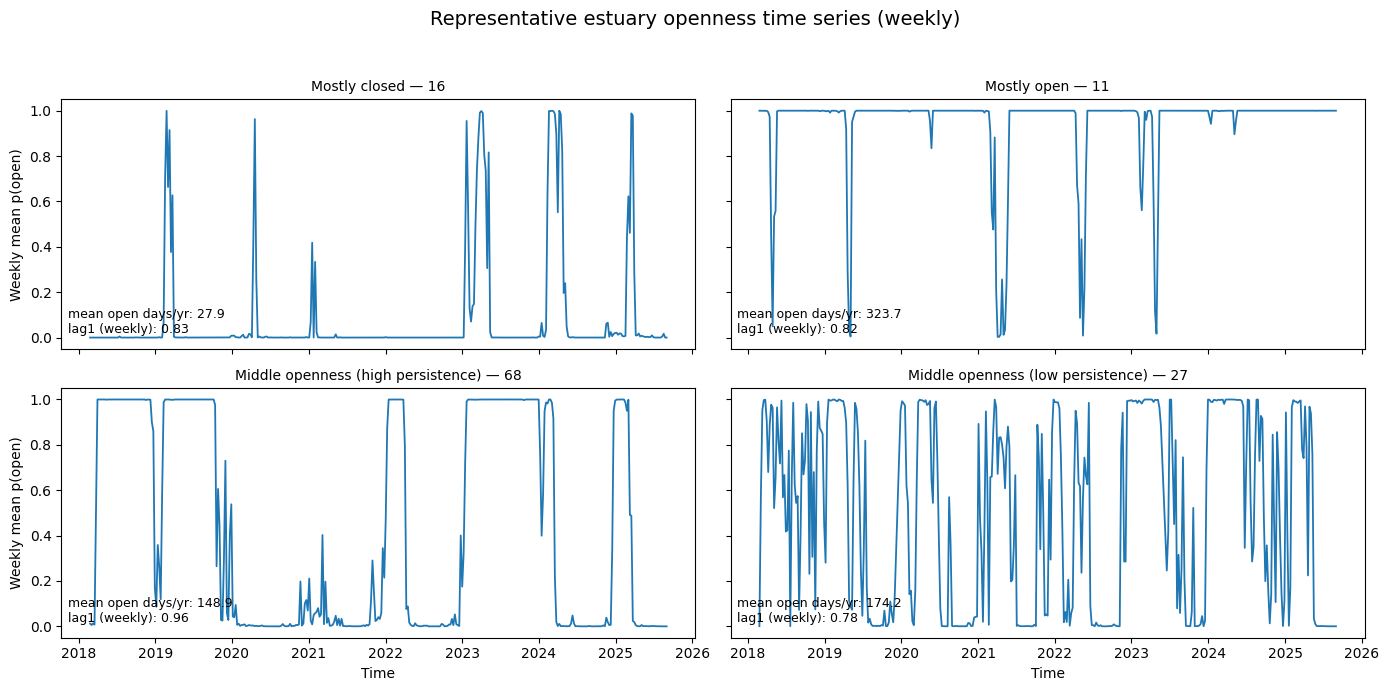

In [109]:
# Make sure indices align
common = mean_open_days.index.intersection(rho1_w.index).intersection(P_w.index)

m_open = mean_open_days.loc[common]
rho1 = rho1_w.loc[common]

# Mostly closed / open
r_closed = m_open.idxmin()
r_open = m_open.idxmax()

# Middle group: pick within the middle 40–60% openness range (adjust if you want)
lo = m_open.quantile(0.4)
hi = m_open.quantile(0.6)
mid_candidates = m_open[(m_open >= lo) & (m_open <= hi)].index

# Two middle examples: most persistent and least persistent
r_mid_persistent = rho1.loc[mid_candidates].idxmax()
r_mid_switchy = rho1.loc[mid_candidates].idxmin()

rep_regions = [r_closed, r_open, r_mid_persistent, r_mid_switchy]
print("Selected regions:", rep_regions)
print(
    pd.DataFrame(
        {
            "mean_open_days": m_open.loc[rep_regions],
            "rho1_weekly": rho1.loc[rep_regions],
        }
    )
)

import matplotlib.pyplot as plt

titles = {
    rep_regions[0]: "Mostly closed",
    rep_regions[1]: "Mostly open",
    rep_regions[2]: "Middle openness (high persistence)",
    rep_regions[3]: "Middle openness (low persistence)",
}

fig, axs = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
axs = axs.flatten()

for ax, r in zip(axs, rep_regions):
    s = P_w.loc[r].copy()
    ax.plot(s.index, s.values, linewidth=1.3)

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{titles[r]} — {r}", fontsize=10)

    # optional: annotate metrics
    ax.text(
        0.01,
        0.05,
        f"mean open days/yr: {m_open[r]:.1f}\nlag1 (weekly): {rho1[r]:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
    )

axs[2].set_xlabel("Time")
axs[3].set_xlabel("Time")
axs[0].set_ylabel("Weekly mean p(open)")
axs[2].set_ylabel("Weekly mean p(open)")

fig.suptitle("Representative estuary openness time series (weekly)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [122]:
def compute_first_probabilistic_transition(
    wide_prob: pd.DataFrame,
    years: range,
    start_month: int,
    kind: str = "open",
    *,
    start_day: int = 1,
    window_days: int = 14,
    open_thresh: float = 0.7,
    close_thresh: float = 0.3,
):
    """
    Compute first probabilistic OPEN or CLOSE per water-year and region
    using rolling mean of p(open).

    Parameters
    ----------
    wide_prob : DataFrame
        Rows = regions, columns = dates (datetime), values = p(open) in [0,1].
    years : range
        Water-year labels.
    start_month : int
        Month defining water-year start.
    kind : {'open','close'}
    window_days : int
        Rolling window (days) for smoothing probability.
    open_thresh, close_thresh : float
        Probability thresholds.

    Returns
    -------
    stats : DataFrame indexed by water_year with q25/q50/q75
    events : DataFrame with per-region event dates and offsets
    """
    assert kind in {"open", "close"}

    wide = wide_prob.copy()
    wide.columns = pd.to_datetime(wide.columns)

    rows = []

    for water_year in years:
        wy_start = pd.Timestamp(year=water_year, month=start_month, day=start_day)
        wy_end = pd.Timestamp(year=water_year + 1, month=start_month, day=start_day)

        mask = (wide.columns >= wy_start) & (wide.columns < wy_end)
        if not mask.any():
            continue

        dates = wide.columns[mask]
        W = wide.loc[:, mask]

        # rolling mean along time
        W_roll = W.T.rolling(f"{window_days}D", min_periods=window_days).mean().T

        for region, row in W_roll.iterrows():
            p = row.values
            if np.all(np.isnan(p)):
                continue

            if kind == "open":
                idx = np.where(p >= open_thresh)[0]
            else:  # close
                idx = np.where(p <= close_thresh)[0]

            if len(idx) == 0:
                first_date = pd.NaT
                offset = np.nan
            else:
                first_date = dates[idx[0]]
                offset = (first_date - wy_start).days

            rows.append(
                {
                    "region": region,
                    "water_year": water_year,
                    "first_event_date": first_date,
                    "offset_days": offset,
                }
            )

    events = pd.DataFrame(rows)

    stats = (
        events.dropna(subset=["offset_days"])
        .groupby("water_year")["offset_days"]
        .quantile([0.25, 0.5, 0.75])
        .unstack()
        .rename(columns={0.25: "q25", 0.5: "q50", 0.75: "q75"})
    )

    return stats, events


wide_prob = full["y_prob"].unstack("date")

open_stats_p, open_events_p = compute_first_probabilistic_transition(
    wide_prob=wide_prob,
    years=range(2018, 2025),
    start_month=10,
    kind="open",
    window_days=14,
    open_thresh=0.8,
)

close_stats_p, close_events_p = compute_first_probabilistic_transition(
    wide_prob=wide_prob,
    years=range(2018, 2025),
    start_month=3,
    kind="close",
    window_days=14,
    close_thresh=0.2,
)

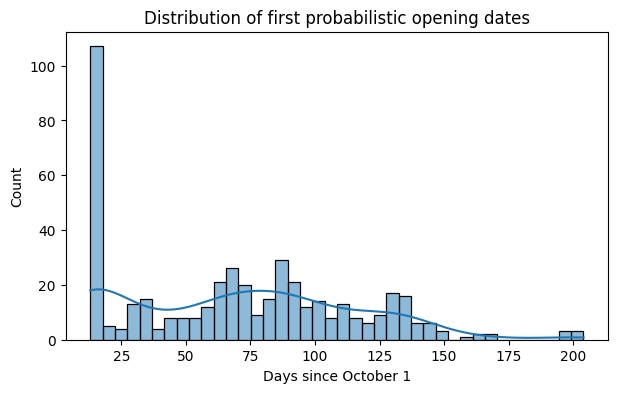

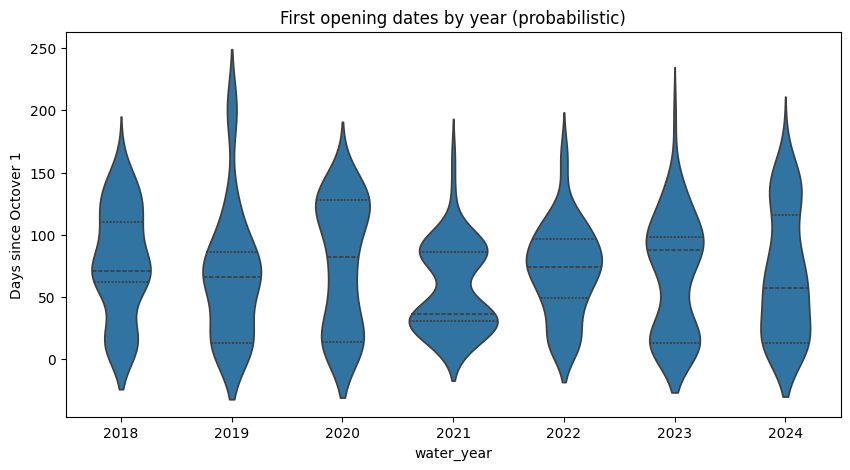

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
sns.histplot(
    open_events_p["offset_days"].dropna(),
    bins=40,
    kde=True,
)
plt.xlabel("Days since October 1")
plt.title("Distribution of first probabilistic opening dates")
plt.show()

plt.figure(figsize=(10, 5))
sns.violinplot(
    data=open_events_p,
    x="water_year",
    y="offset_days",
    inner="quartile",
)
plt.ylabel("Days since Octover 1")
plt.title("First opening dates by year (probabilistic)")
plt.show()

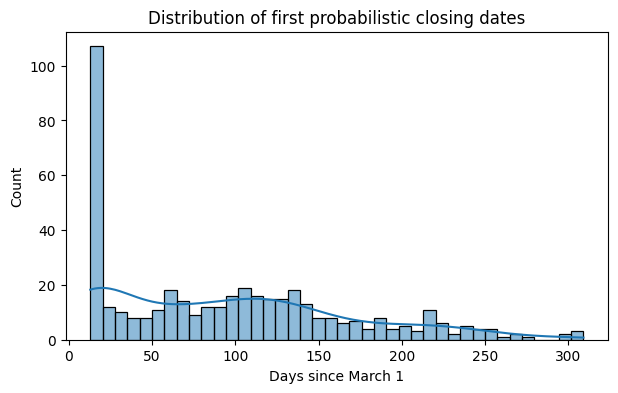

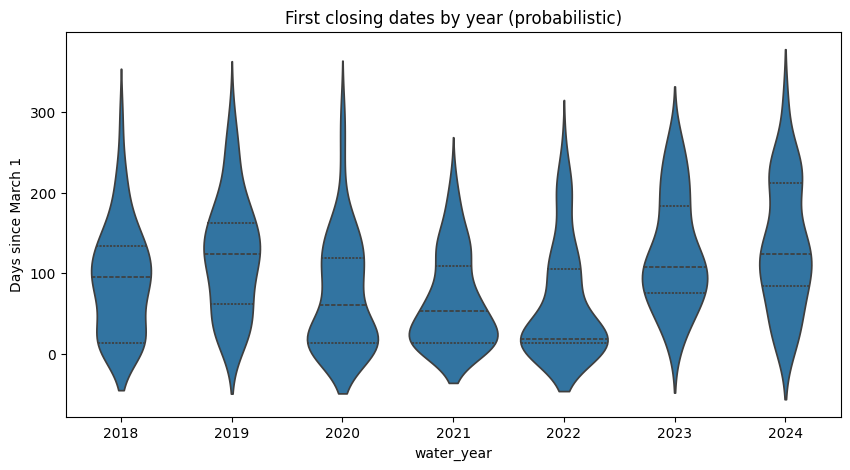

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.histplot(
    close_events_p["offset_days"].dropna(),
    bins=40,
    kde=True,
)
plt.xlabel("Days since March 1")
plt.title("Distribution of first probabilistic closing dates")
plt.show()

plt.figure(figsize=(10, 5))
sns.violinplot(
    data=close_events_p,
    x="water_year",
    y="offset_days",
    inner="quartile",
)
plt.ylabel("Days since March 1")
plt.title("First closing dates by year (probabilistic)")
plt.show()

In [150]:
close_events_p[close_events_p.region == 20]

,region,water_year,first_event_date,offset_days,close_mode
8,20,2018,2018-07-15,136.0,late
80,20,2019,2019-06-11,102.0,mid
152,20,2020,2020-03-14,13.0,early
224,20,2021,2021-03-14,13.0,early
296,20,2022,2022-03-14,13.0,early
368,20,2023,2023-11-27,271.0,late
440,20,2024,2024-09-26,209.0,late


is_bimodal
False    56
True      8
Name: count, dtype: int64

,n_years,frac_early,frac_late,is_bimodal,bimodality_score
region,,,,,
84,7,0.428571,0.428571,True,0.428571
2138,7,0.428571,0.571429,True,0.428571
28,6,0.333333,0.333333,True,0.333333
20,7,0.428571,0.285714,True,0.285714
22,7,0.285714,0.285714,True,0.285714
26,7,0.428571,0.285714,True,0.285714


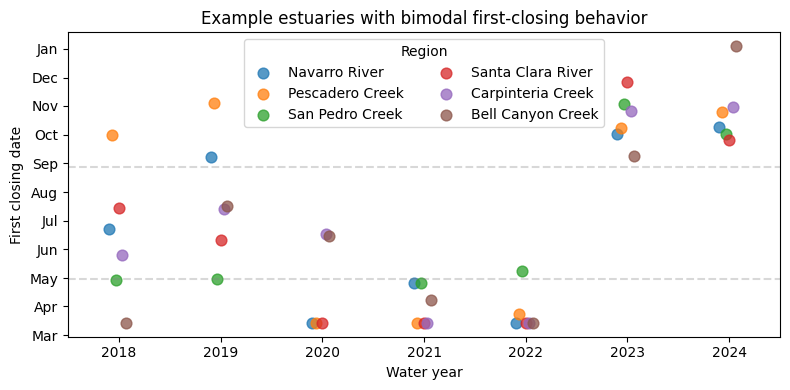

In [181]:
ce = close_events_p.dropna(subset=["offset_days"]).copy()
# Convert offset -> actual date
ce["closing_date"] = pd.to_datetime("2024-03-01") + pd.to_timedelta(ce["offset_days"], unit="D")

EARLY = 60
LATE = 180
MIN_FRAC = 0.25  # at least 25% of years in each mode
MIN_YEARS = 4  # require enough data

rows = []

for region, g in ce.groupby("region"):
    offs = g["offset_days"].values
    n = len(offs)
    if n < MIN_YEARS:
        continue

    frac_early = np.mean(offs < EARLY)
    frac_late = np.mean(offs > LATE)

    rows.append(
        {
            "region": region,
            "n_years": n,
            "frac_early": frac_early,
            "frac_late": frac_late,
            "is_bimodal": (frac_early >= MIN_FRAC) and (frac_late >= MIN_FRAC),
        }
    )

bimodal_df = pd.DataFrame(rows).set_index("region")
display(bimodal_df["is_bimodal"].value_counts())

bimodal_df["bimodality_score"] = np.minimum(bimodal_df["frac_early"], bimodal_df["frac_late"])
bimodal_df["is_bimodal"].fillna(False)

candidates = bimodal_df[(bimodal_df["is_bimodal"]) & (bimodal_df["n_years"] >= 6)].sort_values(
    "bimodality_score", ascending=False
)

example_sites = candidates.head(6).index.tolist()
display(candidates.head(6))

# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# fig, ax = plt.subplots(figsize=(8, 4))

# for r in example_sites:
#     g = ce[ce["region"] == r]
#     ax.scatter(
#         g["water_year"],
#         g["closing_date"],
#         label=str(r),
#         s=60,
#         alpha=0.75,
#     )

# # Format y-axis as months
# ax.yaxis.set_major_locator(mdates.MonthLocator())
# ax.yaxis.set_major_formatter(mdates.DateFormatter("%b"))

# ax.axhline(
#     pd.Timestamp("2024-03-01") + pd.Timedelta(days=EARLY),
#     color="gray",
#     linestyle="--",
#     alpha=0.3,
# )
# ax.axhline(
#     pd.Timestamp("2024-03-01") + pd.Timedelta(days=LATE),
#     color="gray",
#     linestyle="--",
#     alpha=0.3,
# )

# ax.set_xlabel("Water year")
# ax.set_ylabel("First closing date")
# ax.set_title("Example estuaries with bimodal first-closing behavior")
# ax.legend(title="Region", ncol=2)

# plt.tight_layout()
# plt.show()

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)
JITTER = 0.1  # years

fig, ax = plt.subplots(figsize=(8, 4))

for i, r in enumerate(example_sites):
    g = ce[ce["region"] == r]
    name = gdf_points[gdf_points.region == r].iloc[0]["Estuary_Name"]

    # jitter water_year slightly
    x = g["water_year"].astype(float).to_numpy()
    jitter = i / len(example_sites) * 2 * JITTER - JITTER
    x_jittered = x + jitter

    ax.scatter(
        x_jittered,
        g["closing_date"],
        label=name,
        s=60,
        alpha=0.75,
    )

# Format y-axis as months
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.yaxis.set_major_formatter(mdates.DateFormatter("%b"))

# Reference lines (use a representative year for placement)
ax.axhline(
    pd.Timestamp("2024-03-01") + pd.Timedelta(days=EARLY),
    color="gray",
    linestyle="--",
    alpha=0.3,
)
ax.axhline(
    pd.Timestamp("2024-03-01") + pd.Timedelta(days=LATE),
    color="gray",
    linestyle="--",
    alpha=0.3,
)

ax.set_xlabel("Water year")
ax.set_ylabel("First closing date")
ax.set_title("Example estuaries with bimodal first-closing behavior")
ax.legend(title="Region", ncol=2)

# Keep x ticks clean (no jitter in labels)
ax.set_xticks(sorted(ce["water_year"].unique()))
ax.set_xlim(min(ce["water_year"]) - 0.5, max(ce["water_year"]) + 0.5)

plt.tight_layout()
plt.show()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_36441/2616843324.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gdf["is_bimodal"] = gdf["is_bimodal"].fillna(False).astype(bool)


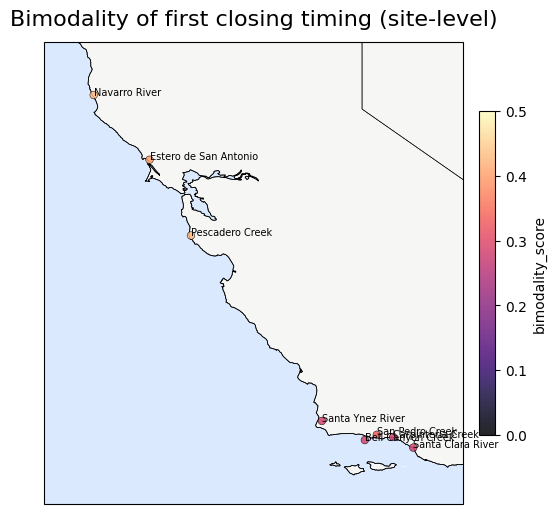

In [176]:
gdf = gdf_points.copy().set_index("region")

# join bimodality columns (will create NaNs where missing)
gdf = gdf.join(
    bimodal_df[["bimodality_score", "is_bimodal"]],
    how="left",
)

# fill missing flags as False; leave score as NaN
gdf["is_bimodal"] = gdf["is_bimodal"].fillna(False).astype(bool)

gdf["bimodality_score"] = gdf["bimodality_score"].fillna(0.0)

vmin = 0.0
vmax = 0.5  # theoretical max

strong = gdf[gdf["is_bimodal"]]

plot_estuaries_ca(
    strong,
    column="bimodality_score",
    cmap="magma",
    vmin=vmin,
    vmax=vmax,
    point_alpha=0.85,
    markersize=30,
    jitter_deg=0.05,
    label_column="Estuary_Name",
    show_labels=True,
    title="Bimodality of first closing timing (site-level)",
    # save_path=SAVE_DIR / "bimodality_score_map.png",
    show=True,
)